Т.к. данные сырые, то их нужно сначала сформировать в датасет. Поэтому выполним сначала 3 пункт по инженерии признаков, затем опишем полученный датасет (2 пункт)

**Библиотеки**

**Сформирован датасет** на реальных данных (резюме) из компании "Б1"

In [2]:
# !pip install pdfplumber python-docx pymupdf pandas scikit-learn
# !pip install textract
# !pip install pywin32
# !pip install pdfplumber PyMuPDF python-docx pytesseract pdf2image
# !pip install category_encoders

import os
import re
import warnings
from docx import Document
import win32com.client
import pdfplumber

import pandas as pd
import numpy as np  
from scipy import stats
import itertools
import math
import matplotlib.pyplot as plt  # для визуализации
import seaborn as sns  # для визуализации
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from factor_analyzer import Rotator
from collections import defaultdict
from scipy.stats import norm  # нормальное распределение
from scipy.stats.mstats import winsorize  # винзоризация
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler  # масштабирование признаков
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder  # перекодирование
from category_encoders import TargetEncoder  # перекодирование
from scipy.stats import kstest, skew, kurtosis  # тест Колмогорова-Смирнова, асимметрия, эксцесс
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

Далее библиотеки, которых не хватает, будем добавлять в том пункте задания, где они нужны

**Формирование датасета**

В рамках исследования был сформирован собственный датасет резюме кандидатов, подававшихся на позиции в сфере консалтинга, аналитики и смежных бизнес-направлений. Источником данных выступили реальные CV кандидатов, разделенные на две категории:

- успешные кандидаты (target = 1);
- неуспешные кандидаты (target = 0).

Основной целью данного этапа являлось создание структурированной базы данных для дальнейшего feature engineering и построения моделей машинного обучения.

In [6]:
DATASET_PATH = "dataset"

records = []

#### Загрузка и парсинг исходных данных
Исходные файлы хранятся в папке `dataset/` в двух директориях: `yes` (кандидаты, получившие оффер) и `no` (отказы после интервью). Для извлечения текста реализована цепочка резервных методов (fallback chain):
- **PDF**: `pdfplumber` → `PyMuPDF (fitz)` → `OCR (pytesseract)`. Если первый метод падает на битом файле или скане, автоматически запускается следующий.
- **DOC/DOCX**: `python-docx` → `win32com.client`. Позволяет корректно читать как современные, так и устаревшие форматы Word.
Все COM-объекты закрываются в блоке `finally` с обработкой исключений, что предотвращает зависание фоновых процессов `WINWORD.EXE`.
#### Предобработка и фильтрация
Выполним следующие преобразования:
1. **Фильтрация мусора**: Игнорируются системные файлы (`~$...`, `.DS_Store`, скрытые папки).
2. **Нормализация текста**: Убираются переносы строк, табуляции и множественные пробелы через `re.sub(r'\s+', ' ', text)`.
3. **Порог валидности**: Файлы, из которых извлечено ≤15 символов (обычно пустые сканы или битые PDF), отсеиваются.
4. **Анонимизация**: Исходные имена файлов удаляются, каждому кандидату присваивается уникальный `candidate_id`.
Результат сохраняется в `DataFrame` с колонками: `text`, `target` (0/1), `candidate_id`.

In [7]:
import os
import re
import warnings
import pdfplumber
import fitz  
from docx import Document
import win32com.client

try:
    import pytesseract
    from pdf2image import convert_from_path
    OCR_AVAILABLE = True
except ImportError:
    OCR_AVAILABLE = False

warnings.filterwarnings("ignore")

def _extract_pdf_plumber(path):
    with pdfplumber.open(path) as pdf:
        return " ".join(page.extract_text() or "" for page in pdf.pages)

def _extract_pdf_fitz(path):
    doc = fitz.open(path)
    text = "".join(page.get_text() for page in doc)
    doc.close()
    return text

def _extract_pdf_ocr(path):
    if not OCR_AVAILABLE:
        raise RuntimeError("OCR недоступен")
    images = convert_from_path(path, dpi=300)
    return " ".join(pytesseract.image_to_string(img, lang='rus+eng') for img in images)

def _extract_docx(path):
    doc = Document(path)
    return "\n".join(p.text for p in doc.paragraphs)

def _extract_doc_win32(path):
    word = win32com.client.Dispatch("Word.Application")
    word.Visible = False
    try:
        doc = word.Documents.Open(os.path.abspath(path))
        text = doc.Content.Text
        doc.Close(SaveChanges=False)
        return text
    finally:
        word.Quit()

def extract_text_robust(file_path):
    ext = os.path.splitext(file_path)[1].lower()
    
    if ext == '.pdf':
        for func in [_extract_pdf_plumber, _extract_pdf_fitz, _extract_pdf_ocr]:
            try:
                return func(file_path)
            except Exception:
                continue
    elif ext in ('.doc', '.docx'):
        # Сначала пробуем нативный парсер для docx, потом win32com
        if ext == '.docx':
            try: return _extract_docx(file_path)
            except Exception: pass
        try: return _extract_doc_win32(file_path)
        except Exception: pass
        
    return ""


DATASET_PATH = os.path.abspath("dataset")
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Папка {DATASET_PATH} не найдена. Проверьте рабочий каталог ноутбука.")

records = []
stats = {"success": 0, "empty": 0, "total": 0}
SUPPORTED_EXT = ('.pdf', '.doc', '.docx')

for label_folder in ["yes", "no"]:
    folder_path = os.path.join(DATASET_PATH, label_folder)
    target = 1 if label_folder == "yes" else 0
    
    for filename in os.listdir(folder_path):
        # Пропускаем системные, временные и неподдерживаемые файлы
        if filename.startswith(('.', '_', '~$')): 
            continue
        if not filename.lower().endswith(SUPPORTED_EXT):
            continue
            
        file_path = os.path.join(folder_path, filename)
        stats["total"] += 1
        
        text = extract_text_robust(file_path)
        # Очищаем от лишних пробелов и переносов
        text_clean = re.sub(r'\s+', ' ', text).strip()
        
        # Фильтр: считаем файл валидным, если извлечено > 15 символов
        if len(text_clean) > 15:
            records.append({
                "filename": filename,
                "text": text_clean,
                "target": target
            })
            stats["success"] += 1
        else:
            stats["empty"] += 1

print("СТАТИСТИКА ЗАГРУЗКИ:")
print(f"Успешно обработано: {stats['success']} / {stats['total']} ({stats['success']/max(stats['total'],1)*100:.1f}%)")
print(f"Пропущено: {stats['empty']}")
if stats['success'] > 0:
    df = pd.DataFrame(records)
    df["candidate_id"] = [f"candidate_{i+1}" for i in range(len(df))]
    df = df.drop(columns=["filename"])
    print(f"Сформирован датасет: {df.shape[0]} записей, {df.shape[1]} колонок")
    display(df.head())

Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because No

СТАТИСТИКА ЗАГРУЗКИ:
Успешно обработано: 597 / 609 (98.0%)
Пропущено: 12
Сформирован датасет: 597 записей, 3 колонок


,text,target,candidate_id
0,ELENA NAUMOVA DETAILS PROFILE Passionate for l...,1,candidate_1
1,Yaschenko Kristina krist.tchechulina@yandex.ru...,1,candidate_2
2,Южаков Дмитрий г. Москва тг: zashitaluzhina; 8...,1,candidate_3
3," Лещанкина Арина Константиновна Female, 24 y...",1,candidate_4
4,Горланкин Егор Андреевич г. Москва | +79127606...,1,candidate_5


##### Результат предобработки. Сформирован датафрейм из 597 записей с тремя колонками: очищенный текст, целевая переменная и анонимизированный ID. Данные готовы к feature engineering.

In [8]:
# Сохранение датафрейма в Excel
df.to_excel("датасет.xlsx", index=False)

# Сохранение в CSV
df.to_csv("датасет.csv", index=False, encoding="utf-8-sig")

3. **Предобработка и инженерия признаков**
* Обработка пропусков 
* Кодирование категориальных признаков 
* Масштабирование числовых признаков 
* Создание новых признаков
* Снижение размерности при необходимости

**Очистка текста и дополнительные функции**

Перед feature engineering, обработаем тексты резюме:

- переведем в нижний регистр;
- удалим переносы строк;
- удалим лишние пробелы;
- преобразуем к единому формату.


In [9]:
def clean_text(text):
    """Basic preprocessing for resume text."""

    text = str(text).lower()

    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\r", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


df["clean_text"] = df["text"].apply(clean_text)

**Функции для извлечения признаков**

Для автоматического извлечения признаков из текстов резюме были реализованы вспомогательные функции.

1. Функция contains_keywords() для определения наличия хотя бы одного ключевого слова или фразы в тексте резюме. Если соответствующее ключевое слово обнаружено, функция возвращает значение 1, в противном случае — 0. Используем для бинарных признаков

2. Функция count_keyword_frequency() для подсчета общего количества упоминаний ключевых слов в тексте. В отличие от бинарного подхода, данная функция позволяет учитывать интенсивность или частоту использования определенных терминов.

In [10]:
def contains_keywords(text, keywords):

    for keyword in keywords:

        pattern = r"\b" + re.escape(keyword) + r"\b"

        if re.search(pattern, text):
            return 1

    return 0


def count_keyword_frequency(text, keywords):

    total = 0

    for keyword in keywords:

        pattern = r"\b" + re.escape(keyword) + r"\b"

        matches = re.findall(pattern, text)

        total += len(matches)

    return total

**Feature Engineering**

Признаки формировались вручную на основе результатов экспертных интервью с рекрутерами и специалистами HR консалтинговой индустрии. Отобранные сигналы отражают характеристики, которые обычно ассоциируются с успешными кандидатами на аналитические и консалтинговые позиции.

Итоговый набор признаков включает:

- образовательные характеристики;
- консалтинговые сигналы;
- технические компетенции;
- лидерские индикаторы;
- внеучебные достижения;
- коммуникационные навыки.


In [11]:
TOP_UNIVERSITIES = [

    # РЭШ
    "рэш",
    "российская экономическая школа",
    "new economic school",
    "nes",

    # ВШЭ
    "вшэ",
    "высшая школа экономики",
    "higher school of economics",
    "national research university higher school of economics",
    "hse",

    # МГУ
    "мгу",
    "московский государственный университет",
    "moscow state university",
    "lomonosov moscow state university",
    "msu",

    # МФТИ
    "мфти",
    "moscow institute of physics and technology",
    "phystech",

    # Бауманка
    "бауман",
    "мгту",
    "мгту им баумана",
    "bauman",
    "bauman moscow state technical university",

    # Финансовый университет
    "финансовый университет",
    "financial university",
    "financial university under the government",

    # СПбГУ
    "спбгу",
    "saint petersburg state university",
    "st. petersburg state university",

    # РАНХиГС
    "ранхигс",
    "ranepa",
    "russian presidential academy",

    # МГИМО
    "мгимо",
    "mgimo",
    "moscow state institute of international relations",

    # ИТМО
    "итмо",
    "itmo",

    # Иннополис
    "иннополис",
    "innopolis university",

    # зарубежные
    "london school of economics",
    "lse",
    "university of london",
    "ucl",
    "oxford",
    "cambridge",
    "hec paris",
    "bocconi",
    "insead",
    "wharton",
    "harvard",
    "stanford",
    "mit",

    # бизнес-школы
    "iscte business school",
    "business school"
]

# ECONOMICS/BUSINESS MAJORS

ECON_MAJORS = [

    # economics
    "economics",
    "экономика",
    "economic",

    # finance
    "finance",
    "финансы",
    "financial economics",
    "corporate finance",
    "international finance",
    "financial markets",
    "финансовые рынки",
    "финансовый анализ",
    "investment analysis",
    "valuation",

    # accounting
    "accounting",
    "financial accounting",
    "ifrs",
    "мсфо",
    "audit",

    # business
    "business",
    "business administration",
    "management",
    "менеджмент",
    "international business",

    # consulting related
    "business analytics",
    "business analysis",
    "market analysis",
    "strategy",
    "corporate strategy",

    # quantitative economics
    "econometrics",
    "economic statistics",
    "risk management",

    # banking
    "banking",
    "investment banking",
    "corporate banking",

    # operations
    "operations management",

    # entrepreneurship
    "entrepreneurship",

    # mba
    "mba"
]

# TECHNICAL / QUANTITATIVE MAJORS

TECH_MAJORS = [

    # CS
    "computer science",
    "computer engineering",
    "software engineering",

    # applied math
    "applied mathematics",
    "прикладная математика",
    "mathematics",

    # informatics
    "informatics",
    "информатика",
    "applied informatics",

    # data science
    "data science",
    "big data",
    "analytics",

    # AI / ML
    "machine learning",
    "artificial intelligence",
    "deep learning",
    "neural networks",

    # programming
    "programming",
    "program developer",

    # engineering
    "engineering",
    "systems engineering",

    # quantitative
    "quantitative methods",
    "quantitative finance",
    "quantitative economics",

    # physics
    "physics",
    "theoretical physics",

    # DS/ML related
    "ml engineer",
    "data engineer",
    "data analyst",
    "data scientist",

    # russian
    "факультет компьютерных наук",
    "пми",
    "математика",
    "теория вероятности",
    "математическое моделирование"
]

# CASE COMPETITIONS

CASE_COMPETITIONS = [

    # english
    "case competition",
    "case championship",
    "business case",
    "case solving",
    "case study",
    "case interview",
    "case school",
    "case club",
    "consulting club",
    "business challenge",

    # russian
    "кейс",
    "кейс-чемпионат",
    "кейс чемпионат",
    "кейс-клуб",  
    "кейс школа",
    "решение кейсов",

    # competitions
    "changellenge",
    "changellenge cup",
    "cup moscow",
    "case-in",
    "cfa research challenge",
    "investment research challenge",
    "ey business case",
    "bcg case competition",
    "mckinsey challenge",
    "oliver wyman case",
    "strategy cup",

    # universities
    "hse case school",
    "fu case club",
    "nes investment research challenge",

    # hackathons / championships
    "hackathon",
    "хакатон",
    "business hackathon",
    "championship"
]

# CONSULTING Keywords

CONSULTING_KEYWORDS = [

    # consulting
    "consulting",
    "consultant",
    "strategy consulting",
    "management consulting",
    "business consulting",
    "advisory",
    "consulting department",

    # strategy
    "strategy",
    "strategic",
    "corporate strategy",
    "business strategy",
    "growth strategy",
    "market entry strategy",

    # analytics
    "business analysis",
    "competitive analysis",
    "industry analysis",
    "analytical thinking",
    "problem solving",
    "critical thinking",

    # operational consulting
    "process optimization",
    "business process",
    "transformation",
    "operational efficiency",


    # russian consulting wording
    "консалтинг",
    "консультант",
    "стратегия",
    "стратегический",
    "бизнес-анализ",
    "анализ бизнеса",
    "анализ рынка",
    "финансовое моделирование",
    "решение бизнес-задач",
    "оптимизация процессов",

    # common consulting tasks
    "presentation",
    "stakeholder",
    "client management",
    "project work",
    "business development"
]

# MARKET RESEARCH ORIENTATION

MARKET_RESEARCH = [

    # market research
    "market research",
    "industry research",
    "industry analysis",
    "competitive analysis",
    "competitor analysis",
    "market intelligence",
    "market trends",
    "market sizing",
    "market insights",

    # analytics
    "benchmarking",
    "consumer analysis",
    "customer analysis",
    "segmentation",
    "market segmentation",

    # russian wording
    "исследование",
    "исследование рынка",
    "анализ рынка",
    "анализ отрасли",
    "анализ конкурентов",
    "рыночная аналитика",
    "конкурентный анализ",
    "маркетинговое исследование",
    "аналитический обзор",
    "финансовый анализ",
    "инвестиционный анализ",
    "экономическое исследование",

    # finance / business
    "market overview",
    "business research",
    "macro analysis",
    "industry trends"
]

# VALUATION

VALUATION = [

    # valuation
    "valuation",
    "business valuation",
    "company valuation",
    "equity valuation",
    "enterprise valuation",
    "valuation model",

    # financial modeling
    "financial modeling",
    "financial model",
    "financial analysis",
    "financial forecasting",
    "forecast model",
    "three-statement model",

    # DCF
    "dcf",
    "discounted cash flow",
    "multiples",
    "trading multiples",
    "comparable companies",
    "comps analysis",
    "precedent transactions",

    # finance metrics
    "ebitda",
    "revenue growth",
    "cash flow",
    "free cash flow",
    "npv",
    "irr",
    "wacc",
    "discount rate",
    "terminal value",

    # russian
    "оценка бизнеса",
    "оценка стоимости",
    "финансовое моделирование",
    "финансовый анализ",
    "инвестиционный анализ",
    "ставка дисконтирования",
    "денежный поток",
    "мультипликатор",
    "анализ отчетности",
    "финансовая отчетность",
    "бизнес-кейс",
    "экономическая эффективность"
]

# INTERNSHIP / EARLY CAREER EXPERIENCE

INTERNSHIP = [

    # english
    "intern",
    "internship",
    "summer intern",
    "summer internship",
    "trainee",
    "graduate trainee",
    "analyst intern",
    "research intern",
    "assistant",

    # russian
    "стажер",
    "стажировка",
    "практикант",
    "ассистент",
    "младший аналитик",
    "учебный ассистент",

    # consulting wording
    "intern analyst",
    "junior analyst",
    "business analyst intern",

    # finance
    "investment banking intern",
    "equity research intern",

    # university activity
    "teaching assistant",
    "research assistant"
]

# CONSULTING EXPERIENCE

CONSULTING_EXPERIENCE = [

    # Big 4
    "ey",
    "ernst",
    "pwc",
    "pricewaterhousecoopers",
    "тедо",
    "технологии доверия",
    "deloitte",
    "делойт",
    "дрт",
    "kpmg",
    "kept",
    "кепт",
    "кпмг",
    "b1",
    "б1",

    # strategy consulting
    "mckinsey",
    "bcg",
    "boston consulting group",
    "bain",
    "oliver wyman",
    "strategy&",
    "strategy and",
    "strategy partners",
    "roland berger",

    # tech / transformation
    "accenture",
    "ibm",
    "аксеникс",

    # russian consulting
    "fbk",
    "фбк",
    "yakov and partners",
    "yakov",
    "tecnologies of trust",

    # roles
    "consultant",
    "business analyst",
    "strategy analyst",
    "associate consultant",
    "junior consultant",
    "analyst",

    # russian roles
    "консультант",
    "аналитик",
    "бизнес-аналитик",
    "стратегический консультант",
    "младший консультант"
]

# TOP EMPLOYERS EXPERIENCE

BIG_BRANDS = [

    # banks
    "raiffeisen",
    "raiffeisenbank",
    "райффайзен",
    "sber",
    "сбер",
    "sberbank",
    "сбербанк",
    "vtb",
    "втб",
    "alfa",
    "alfabank",
    "альфа",
    "gazprombank",
    "тинькофф",
    "tinkoff",

    # telecom / tech
    "мегафон",
    "megafon",
    "yandex",
    "яндекс",
    "vk",
    "вк",
    "ozon",
    "озон",
    "wildberries",

    # government / regulators
    "central bank",
    "cbr",
    "bank of russia",
    "центральный банк",
    "цб",
    "министерство",
    "government",

    # industry leaders
    "aeroflot",
    "полиметалл",
    "magnit",
    "магнит",
    "x5",
    "пятерочка",
    "лента"
]

# CLIENT-FACING SKILLS

CLIENT_FACING = [

    # english
    "client communication",
    "client interaction",
    "stakeholder",
    "stakeholder management",
    "presentation",
    "presentations",
    "business communication",
    "negotiation",
    "customer interaction",
    "public speaking",
    "consulting session",
    "team communication",
    "facilitation",

    # consulting wording
    "client management",
    "client support",
    "work with clients",
    "client service",
    "business correspondence",

    # russian
    "коммуникация",
    "деловая коммуникация", 
    "деловая переписка",
    "переговоры",
    "клиент",
    "клиенты",
    "взаимодействие с клиентами",
    "работа с клиентами",
    "коммуникативные навыки",
    "навыки коммуникации",
    "подготовка презентаций",
    "выступления",
    "публичные выступления"
]

# LEADERSHIP

LEADERSHIP = [

    # english
    "leader",
    "lead",
    "team lead",
    "project manager",
    "project management",
    "coordinator",
    "initiative",
    "ownership",
    "mentoring",
    "supervision",
    "managed",
    "led",
    "organized",
    "founded",

    # consulting wording
    "managed projects",
    "project coordination",
    "business development",

    # russian
    "руководитель",
    "лидер",
    "лидерство",
    "организатор",
    "координатор",
    "управление проектами",
    "руководил",
    "организовал",
    "инициативность",
    "самостоятельность",
    "ответственность",
    "командная работа",
    "управление командой",
    "ментор"
]

# PROJECT MANAGEMENT

PROJECT_MANAGEMENT = [

    # english
    "project management",
    "pm",
    "program management",
    "delivery",
    "workflow",
    "roadmap",
    "agile",
    "scrum",
    "kanban",
    "task management",

    # consulting / business
    "project team",
    "project coordination",
    "business process",
    "project delivery",
    "cross-functional project",

    # russian
    "управление проектами",
    "ведение проектов",
    "координация",
    "планирование",
    "бизнес-процесс",
    "дедлайн",
    "управление задачами",
    "реализация проекта",
    "проектная работа",
    "командный проект",

    # tools
    "jira",
    "trello",
    "asana",
    "ms project"
]

# PRESENTATION 

PRESENTATION = [

    # инструменты
    "powerpoint",
    "power point",
    "ppt",
    "think-cell",
    "canva",
    "figma",
    "google slides",
    "ms powerpoint",

    # презентации
    "презентация",
    "презентации",
    "подготовка презентаций",
    "создание презентаций",
    "оформление презентаций",
    "разработка презентаций",
    "презентационные материалы",
    "подготовка слайдов",
    "визуализация данных",
    "подготовка отчетов",
    "оформление отчетов",
    "подготовка аналитических материалов",

    # consulting wording
    "подготовка клиентских презентаций",
    "подготовка материалов для клиента",
    "подготовка executive summary",
    "подготовка аналитических презентаций",
    "визуализация аналитики",

    # english
    "presentation",
    "presentation skills",
    "storytelling",
    "business storytelling",
    "pitch",
    "pitch deck",
    "client presentation",
    "executive presentation",
    "data visualization"
]

# COMMUNICATION 

COMMUNICATION = [

    # коммуникация
    "коммуникация",
    "коммуникативные навыки",
    "деловая коммуникация",  
    "деловая переписка",
    "навыки общения",
    "ведение переговоров",
    "переговоры",
    "взаимодействие",
    "взаимодействие с клиентами",
    "работа с клиентами",
    "клиентоориентированность",

    # teamwork
    "командная работа",
    "работа в команде",
    "взаимодействие в команде",
    "кросс-функциональное взаимодействие",
    "межфункциональное взаимодействие",
    "коллаборация",
    "сотрудничество",

    # consulting soft skills
    "ведение встреч",
    "фасилитация",
    "обсуждение с заказчиком",
    "коммуникация со стейкхолдерами",
    "поддержка клиентов",

    # personality
    "эмпатия",
    "гибкость",
    "адаптивность",
    "стрессоустойчивость",
    "soft skills",

    # english
    "communication",
    "teamwork",
    "team player",
    "business communication",
    "negotiation",
    "collaboration",
    "stakeholder communication"
]

# PROBLEM SOLVING

PROBLEM_SOLVING = [

    # аналитика
    "аналитическое мышление",
    "критическое мышление",
    "структурное мышление",
    "логическое мышление",
    "системное мышление",
    "анализ данных",
    "обработка данных",
    "анализ информации",
    "интерпретация данных",

    # решение задач
    "решение задач",
    "решение бизнес-задач",
    "решение кейсов",
    "поиск решений",
    "оптимизация",
    "поиск закономерностей",
    "выявление закономерностей",
    "принятие решений",
    "анализ проблем",
    "problem solving",


    # consulting wording
    "бизнес-анализ",
    "стратегический анализ",
    "рыночный анализ",
    "конкурентный анализ",
    "анализ отрасли",
    "case solving",
    "business case",

    # personality
    "внимание к деталям",
    "самостоятельность",
    "обучаемость",
    "быстрая обучаемость",
    "способность быстро обучаться",
    "адаптация к новым задачам",

    # english
    "analytical thinking",
    "critical thinking",
    "structured thinking",
    "quantitative analysis",
    "business analysis",
    "optimization",
    "research"
]

# EXCEL

EXCEL = [

    "excel",

    # formulas
    "vlookup",
    "xlookup",
    "hlookup",
    "index match",
    "sumifs",
    "pivot table",
    "pivot",
    "power query",

    # russian
    "эксель",
    "сводные таблицы",
    "сводная таблица",
    "формулы excel",
    "работа с таблицами",
    "обработка данных в excel",
    "аналитика в excel",
    "дашборд",
    "отчетность"
]

# SQL 

SQL = [

    # sql
    "sql",
    "postgresql",
    "mysql",
    "sqlite",
    "oracle sql",
    "sql server",

    # operations
    "join",
    "subquery",
    "window functions",
    "etl",
    "database",

    # data
    "data warehouse",
    "dwh",

    # russian
    "sql запросы",
    "работа с базами данных",
    "базы данных",
    "обработка данных",
    "извлечение данных",
    "аналитика данных",
    "postgresql",
    "mysql",

    # big data
    "spark",
    "hdfs"
]

# PYTHON

PYTHON = [

    # python
    "python",
    "python3",

    # libraries
    "pandas",
    "numpy",
    "sklearn",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "plotly",
    "scipy",
    "statsmodels",
    "tensorflow",
    "keras",
    "pytorch",

    # ML / DS
    "machine learning",
    "deep learning",
    "data science",
    "nlp",
    "computer vision",

    # coding
    "programming",
    "coding",
    "automation",
    "scripting",

    # russian
    "питон",
    "python разработка",
    "анализ данных на python",
    "машинное обучение",
    "обработка данных",
    "автоматизация",
    "разработка моделей",
    "нейронные сети",
    "искусственный интеллект",

    # tools
    "jupyter",
    "google colab",
    "git",
    "docker"
]

# STATISTICS

STATISTICS = [

    # statistics
    "statistics",
    "mathematical statistics",
    "probability",
    "probability theory",
    "econometrics",
    "quantitative methods",

    # analytics
    "regression",
    "hypothesis testing",
    "time series",
    "bayesian methods",

    # math
    "linear algebra",
    "calculus",
    "optimization",

    # russian
    "математическая статистика",
    "теория вероятностей",
    "эконометрика",
    "статистика",
    "количественный анализ",
    "регрессия",
    "временные ряды",
    "байесовские методы",
    "математический анализ",
    "линейная алгебра",
    "дискретная математика",
    "математическое моделирование"
]

# DATA ANALYSIS

DATA_ANALYSIS = [

    # analysis
    "research",
    "data-driven",

    # russian
    "аналитика",
    "анализ данных",
    "обработка данных",
    "бизнес-аналитика",
    "финансовая аналитика",
    "рыночная аналитика",
    "аналитические навыки",
    "визуализация данных",
    "подготовка аналитики"
]

ADVANCED_ML = [
    "pytorch",
    "bert",
    "transformer",
    "yolo",
    "docker",
    "hdfs",
    "computer vision",
    "deep learning",
    "nlp"
]

# OLYMPIADS

OLYMPIADS = [

    "olympiad",
    "олимпиада",
    "всош",
    "всероссийская олимпиада школьников",
    "мос",
    "мош",
    "олимпиада по экономике",
    "олимпиада по математике",
    "олимпиада по информатике",
    "олимпиада студентов",
    "я профессионал",
    "высшая лига",
    "победитель олимпиады",
    "призер олимпиады",
    "финалист олимпиады"

]

# SCHOLARSHIPS 
SCHOLARSHIPS = [

    # english
    "scholarship",
    "academic scholarship",
    "merit scholarship",
    "award",
    "awarded",
    "honors",
    "distinction",

    # russian
    "стипендия",
    "академическая стипендия",
    "повышенная стипендия",
    "грант",
    "награжден",
    "награда",
    "грамота",
    "диплом",
    "лауреат",
    "победитель",
    "призер",
    "отличие",
    "академические достижения",
    "успеваемость",

    # university wording
    "scholar",
    "dean list",
    "honour"
]

# CFA 

CFA = [

    "cfa",
    "cfa institute",
    "cfa research challenge",
    "equity research"
]


# ACADEMIC EXPERIENCE

RESEARCH = [

    # english
    "research assistant",
    "researcher",
    "publication",
    "academic research",
    "scientific research",
    "working paper",
    "conference paper",

    # university work
    "teaching assistant",
    "educational assistant",
    "laboratory",
    "lab",
    "research project",

    # russian
    "исследовательская работа",
    "научная работа",
    "научное исследование",
    "научная статья",
    "публикация",
    "конференция",
    "доклад",
    "академическая деятельность",
    "ассистент преподавателя",
    "учебный ассистент",
    "лаборатория",
    "аналитический центр",

    # soft academic
    "empirical research"
]

# EXTRACURRICULAR ACTIVITIES

EXTRACURRICULAR = [

    # english
    "student club",
    "community",
    "volunteer",
    "volunteering",
    "challenge",
    "contest",
    "competition",
    "hackathon",
    "case championship",
    "case competition",
    "business game",
    "debate club",
    "startup club",
    "conference",
    "forum",
    "summer school",
    "bootcamp",

    "клуб",
    "кейс-клуб", 
    "кейс школа", 
    "кейс-чемпионат",
    "чемпионат",
    "соревнование",
    "конкурс",
    "хакатон",
    "волонтер",
    "волонтерство",
    "сообщество",
    "студенческая организация",
    "студенческий клуб",
    "дебатный клуб",
    "бизнес-клуб",
    "инвест-клуб",
    "участие",
    "форум",
    "конференция",
    "летняя школа",
    "акселератор",
    "инкубатор",
    
    "campus",
    "case club",
    "case school",
    "changellenge",
    "olympiad",
    "олимпиада",
    "challenge cup",
    "research challenge",

    "ментор",
    "ambassador"
]
# ADVANCED ENGLISH

ENGLISH_ADVANCED = [

    # levels
    "c1",
    "c2",
    "upper-intermediate",
    "advanced english",
    "fluent english",
    "professional english",
    "business english",

    # exams
    "ielts",
    "toefl",
    "cae",
    "cambridge english",
    "fce",
    "toeic",

    # russian
    "английский c1",
    "английский c2",
    "свободный английский",
    "продвинутый английский",
    "деловой английский",
    "английский upper-intermediate",
    "английский advanced",

    # wording from resumes
    "english – c1",
    "english - c1",
    "английский — c1",
    "английский - c1",
    "english – upper-intermediate",
    "upper intermediate",
    "advanced level",

    # international experience
    "study abroad",
    "exchange program",
    "international program"
]

# SECOND FOREIGN LANGUAGE

SECOND_LANGUAGE = [

    # languages english
    "spanish",
    "chinese",
    "german",
    "french",
    "italian",
    "japanese",
    "korean",
    "portuguese",
    "arabic",

    # russian names
    "испанский",
    "китайский",
    "немецкий",
    "французский",
    "итальянский",
    "японский",
    "корейский",
    "португальский",
    "арабский",

    # wording
    "второй иностранный язык",
    "foreign language",
    "language proficiency",
    "language skills",

    # mobility / international
    "international mobility",
    "study abroad",
    "erasmus"
]


Формирование признакового пространства проводилось на основе трёх источников: анализа академической литературы по HR-аналитике, изучения требований консалтинговых компаний и результатов экспертных интервью с рекрутерами (ex-Big4, ex-Big3). Всего сформировано 28 признаков, сгруппированных по категориям:

1. **Образовательные характеристики:** `top_university`, `econ_major`, `tech_major`, `high_gpa`.
2. **Консалтинговая ориентация:** Счётчиковые признаки на основе поиска ключевых слов: `consulting_keywords_count`, `valuation_count`, `market_research_count`, `case_competitions_count`.
3. **Профессиональный опыт:** `internship`, `consulting_experience`, `big_brands`, `research_count`.
4. **Технические и аналитические навыки:** `python_count`, `sql_count`, `excel_count`, `statistics_count`, `data_analysis_count`.
5. **Soft skills и лидерство:** `leadership_count`, `project_management_count`, `presentation_count`, `communication_count`, `problem_solving_count`, `second_language`.
6. **Внеучебные достижения:** `olympiads`, `scholarships`, `cfa`, `english_advanced`, `extracurricular_activity`.

Сформируем бинарные и числовые признаки 

In [12]:
BINARY_FEATURES = {
    "top_university": TOP_UNIVERSITIES,
    "internship": INTERNSHIP,
    "tech_major": TECH_MAJORS,
    "econ_major": ECON_MAJORS,
    "consulting_experience": CONSULTING_EXPERIENCE,
    "big_brands": BIG_BRANDS,
    "olympiads": OLYMPIADS,
    "scholarships": SCHOLARSHIPS,
    "cfa": CFA,
    "english_advanced": ENGLISH_ADVANCED,
    "second_language": SECOND_LANGUAGE
}

In [13]:
COUNT_FEATURES = {
    "consulting_keywords": CONSULTING_KEYWORDS,
    "market_research": MARKET_RESEARCH,
    "valuation": VALUATION,
    "client_facing": CLIENT_FACING,
    "leadership": LEADERSHIP,
    "project_management": PROJECT_MANAGEMENT,
    "presentation": PRESENTATION,
    "communication": COMMUNICATION,
    "problem_solving": PROBLEM_SOLVING,
    "excel": EXCEL,
    "sql": SQL,
    "python": PYTHON,
    "statistics": STATISTICS,
    "data_analysis": DATA_ANALYSIS,
    "research": RESEARCH,
    "case_competitions": CASE_COMPETITIONS
}


In [14]:
# Бинарные
for feature_name, keywords in BINARY_FEATURES.items():

    df[feature_name] = df["clean_text"].apply(
        lambda x: contains_keywords(x, keywords)
    )

# Числовые
for feature_name, keywords in COUNT_FEATURES.items():

    df[feature_name + "_count"] = df["clean_text"].apply(
        lambda x: count_keyword_frequency(x, keywords)
    )

#### Типы формируемых признаков
В проекте использовались два основных типа признаков:
1. Бинарные (0/1) – фиксируют факт наличия хотя бы одного ключевого слова или достижения из соответствующего словаря.
*Примеры: high_gpa, english_advanced, olympiad, scholarship, cfa_related, top_university.*
2. Счётчиковые (int) – фиксируют общую частоту упоминаний всех ключевых слов из словаря в тексте резюме.
*Примеры: consulting_keywords_count, valuation_count, leadership_count, communication_count, problem_solving_count.*

In [15]:
feature_columns = [
    col for col in df.columns
    if col not in ["text", "clean_text", "target", "candidate_id"]
]

df_model = df[["target"] + feature_columns]

print(df_model.shape)

df_model.head()

(597, 28)


,target,top_university,internship,tech_major,econ_major,consulting_experience,big_brands,olympiads,scholarships,cfa,...,presentation_count,communication_count,problem_solving_count,excel_count,sql_count,python_count,statistics_count,data_analysis_count,research_count,case_competitions_count
0,1,1,1,1,1,0,0,0,1,0,...,2,1,7,1,1,0,1,7,1,2
1,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,1,1,1,0,1,1,...,0,0,0,1,1,2,1,0,1,0
3,1,1,1,1,1,1,0,0,0,0,...,0,4,2,0,0,0,0,2,0,0
4,1,1,0,1,1,1,1,0,0,0,...,1,0,1,1,1,6,4,1,0,2


In [16]:
numeric_df = df.select_dtypes(include=["number"])

numeric_df.mean().sort_values(ascending=False).head

<bound method NDFrame.head of python_count                 1.706868
presentation_count           1.681742
excel_count                  1.363484
problem_solving_count        1.301508
consulting_keywords_count    1.165829
valuation_count              1.041876
sql_count                    1.033501
data_analysis_count          0.954774
communication_count          0.897822
case_competitions_count      0.857621
consulting_experience        0.802345
top_university               0.753769
econ_major                   0.748744
project_management_count     0.713568
client_facing_count          0.693467
leadership_count             0.666667
internship                   0.629816
statistics_count             0.596315
big_brands                   0.489112
market_research_count        0.470687
target                       0.469012
english_advanced             0.432161
second_language              0.356784
tech_major                   0.251256
scholarships                 0.190955
research_count      

#### Анализ средних значений признаков

Выше представлены средние значения всех признаков датасета, отсортированные по убыванию. 

**Ключевые выводы:**
1. **Технические навыки** (`python_count`, `excel_count`, `sql_count`) и **консалтинговые термины** (`consulting_keywords_count`, `valuation_count`) имеют наибольшие средние значения (>1.0), что указывает на их частое упоминание в резюме. Кандидаты активно используют эти ключевые слова для повышения заметности.
2. **Бинарные признаки достижений** (`olympiads`, `cfa`, `scholarships`) имеют низкие средние (<0.2), что ожидаемо: олимпиады, сертификаты и стипендии — редкие маркеры.
3. **Целевая переменная** `target ≈ 0.48` подтверждает баланс классов: ~48% кандидатов получили оффер, что позволяет использовать `accuracy` без коррекции на дисбаланс.


In [17]:
# Сохранение датафрейма в Excel
df.to_excel("датасет_признаки.xlsx", index=False)

# Сохранение в CSV
df.to_csv("датасет_признаки.csv", index=False, encoding="utf-8-sig")

In [18]:
df_no_text = df.drop(columns=['text', 'clean_text'])

In [19]:
# Сохранение датафрейма в Excel
df_no_text.to_excel("датасет_без_текста.xlsx", index=False)

# Сохранение в CSV
df_no_text.to_csv("датасет_без_текста.csv", index=False, encoding="utf-8-sig")

2. **Разведочный анализ данных**
* Анализ структуры данных 
* Проверка пропусков, дубликатов и выбросов 
* Анализ распределений признаков 
* Корреляционный анализ 
* Визуализация ключевых тенденций и зависимостей

Проведем первичный анализ сформированного датасета, чтобы выявить ключевые свойства данных, оценить качество признаков и определить возможные проблемы перед построением моделей.

In [20]:
df = pd.read_excel('датасет_без_текста.xlsx')
df.head()

,target,candidate_id,top_university,internship,tech_major,econ_major,consulting_experience,big_brands,olympiads,scholarships,...,presentation_count,communication_count,problem_solving_count,excel_count,sql_count,python_count,statistics_count,data_analysis_count,research_count,case_competitions_count
0,1,candidate_1,1,1,1,1,0,0,0,1,...,2,1,7,1,1,0,1,7,1,2
1,1,candidate_2,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,candidate_3,1,1,0,1,1,1,0,1,...,0,0,0,1,1,2,1,0,1,0
3,1,candidate_4,1,1,1,1,1,0,0,0,...,0,4,2,0,0,0,0,2,0,0
4,1,candidate_5,1,0,1,1,1,1,0,0,...,1,0,1,1,1,6,4,1,0,2


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   target                     597 non-null    int64 
 1   candidate_id               597 non-null    object
 2   top_university             597 non-null    int64 
 3   internship                 597 non-null    int64 
 4   tech_major                 597 non-null    int64 
 5   econ_major                 597 non-null    int64 
 6   consulting_experience      597 non-null    int64 
 7   big_brands                 597 non-null    int64 
 8   olympiads                  597 non-null    int64 
 9   scholarships               597 non-null    int64 
 10  cfa                        597 non-null    int64 
 11  english_advanced           597 non-null    int64 
 12  second_language            597 non-null    int64 
 13  consulting_keywords_count  597 non-null    int64 
 14  market_res

****Вывод: Датасет содержит 596 строк и 29 столбцов.****

Целевая переменная target – бинарная (0 – отказ, 1 – оффер).

28 признаков: 11 бинарных (университет, стажировка, олимпиады и др.) и 17 числовых (счетчики ключевых слов).

Пропуски отсутствуют (все столбцы имеют 596 ненулевых значений).

Идентификатор candidate_id не участвует в анализе.

**Анализ выбросов**

Для числовых признаков (счетчики) выбросы могут искажать статистику. Применим метод IQR и визуализируем с помощью boxplot.

In [22]:
# Определяем бинарные и числовые признаки
binary_features = [
    'top_university', 'internship', 'tech_major', 'econ_major',
    'consulting_experience', 'big_brands', 'olympiads', 'scholarships',
    'cfa', 'english_advanced', 'second_language'
]

numeric_features = [
    'consulting_keywords_count', 'market_research_count', 'valuation_count',
    'client_facing_count', 'leadership_count', 'project_management_count',
    'presentation_count', 'communication_count', 'problem_solving_count',
    'excel_count', 'sql_count', 'python_count', 'statistics_count',
    'data_analysis_count', 'research_count', 'case_competitions_count'
]

# Функция подсчёта выбросов по IQR
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

# Для числовых признаков
outliers_numeric = {col: count_outliers_iqr(df[col]) for col in numeric_features}

print("Выбросы в числовых признаках")
for k, v in sorted(outliers_numeric.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {v}")

Выбросы в числовых признаках
statistics_count: 148
valuation_count: 77
sql_count: 77
case_competitions_count: 70
research_count: 64
client_facing_count: 58
python_count: 52
project_management_count: 43
leadership_count: 36
market_research_count: 23
consulting_keywords_count: 18
problem_solving_count: 12
excel_count: 9
data_analysis_count: 9
communication_count: 5
presentation_count: 2


Большинство кандидатов упоминает термины умеренно, но некоторые резюме содержат десятки повторений (например, кандидаты, перечисляющие множество проектов с «valuation», или активно использующие ключевые слова консалтинга).

Это может быть особенностью «многословных» резюме.

Для работы с линейными моделями логарифмируем переменные, для деревьев и градиентного бустинга можем оставить.

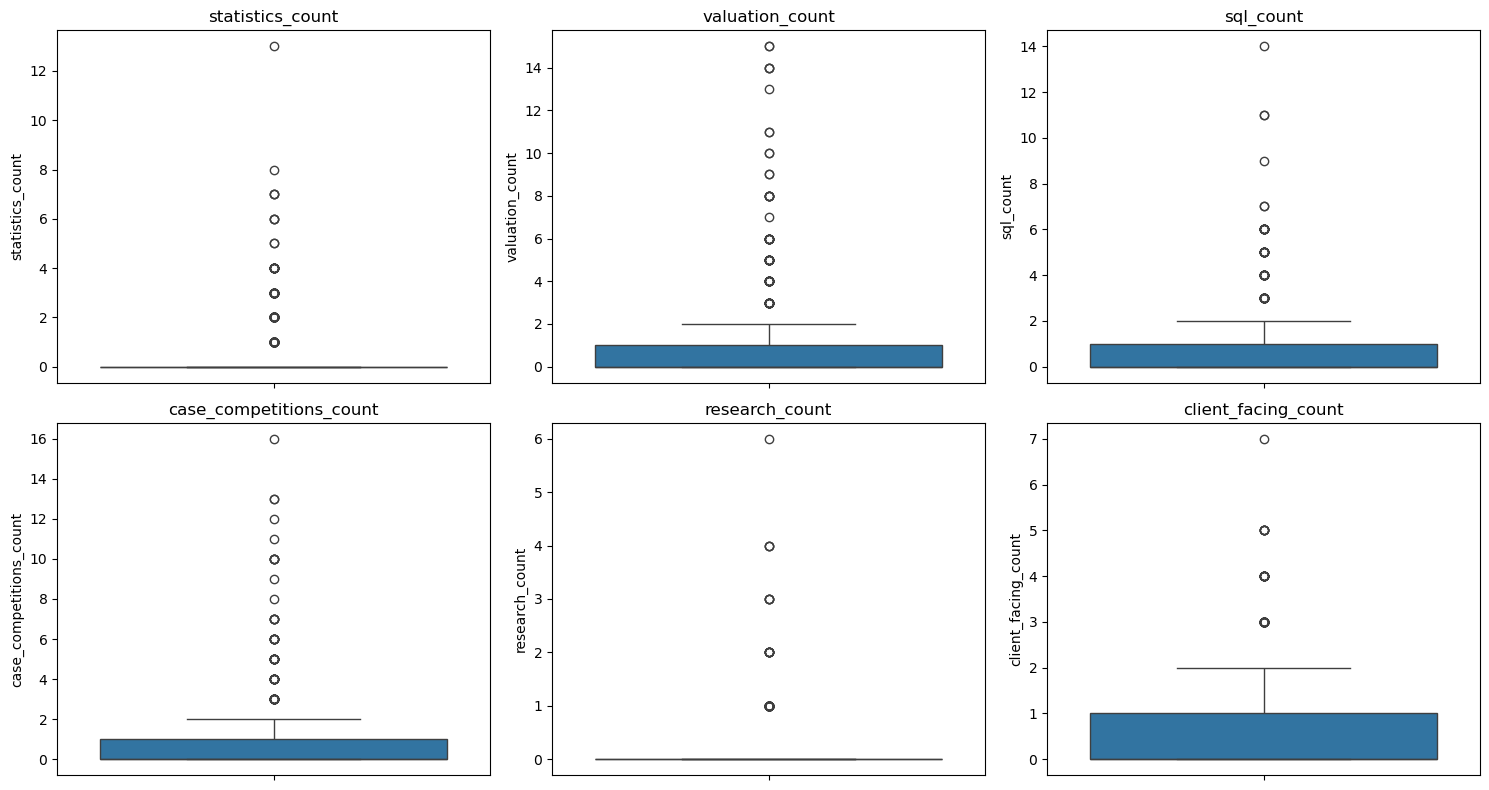

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Пересоздаём словарь с количеством выбросов для числовых признаков
outliers_dict = {col: count_outliers_iqr(df[col]) for col in numeric_features}

# Сортируем по убыванию и берём топ-6
top_outliers = sorted(outliers_dict, key=outliers_dict.get, reverse=True)[:6]

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_outliers):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

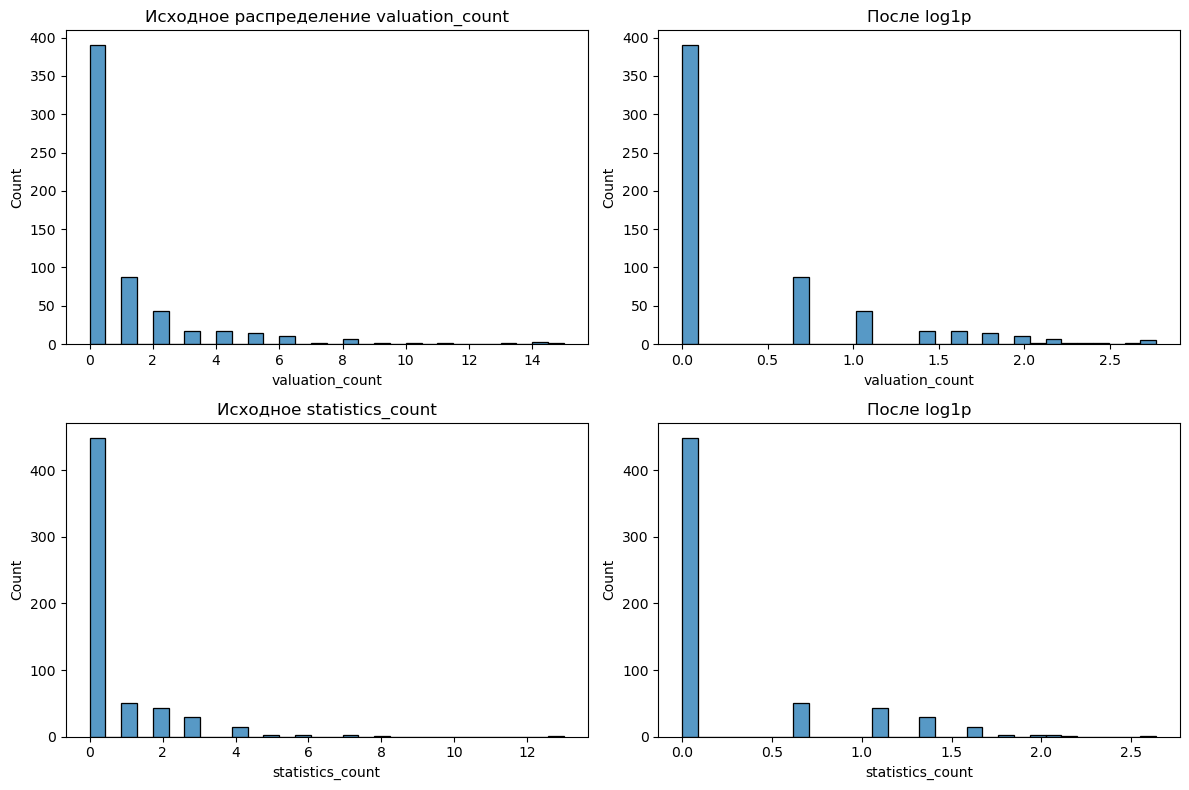

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['valuation_count'], bins=30, ax=axes[0,0])
axes[0,0].set_title('Исходное распределение valuation_count')
sns.histplot(np.log1p(df['valuation_count']), bins=30, ax=axes[0,1])
axes[0,1].set_title('После log1p')
sns.histplot(df['statistics_count'], bins=30, ax=axes[1,0])
axes[1,0].set_title('Исходное statistics_count')
sns.histplot(np.log1p(df['statistics_count']), bins=30, ax=axes[1,1])
axes[1,1].set_title('После log1p')
plt.tight_layout()
plt.show()

Количественные признаки (счетчики ключевых слов) имеют асимметричное распределение с длинным правым хвостом. Это типично для текстовых частот: большинство кандидатов используют ключевые слова умеренно, а небольшая часть – очень активно

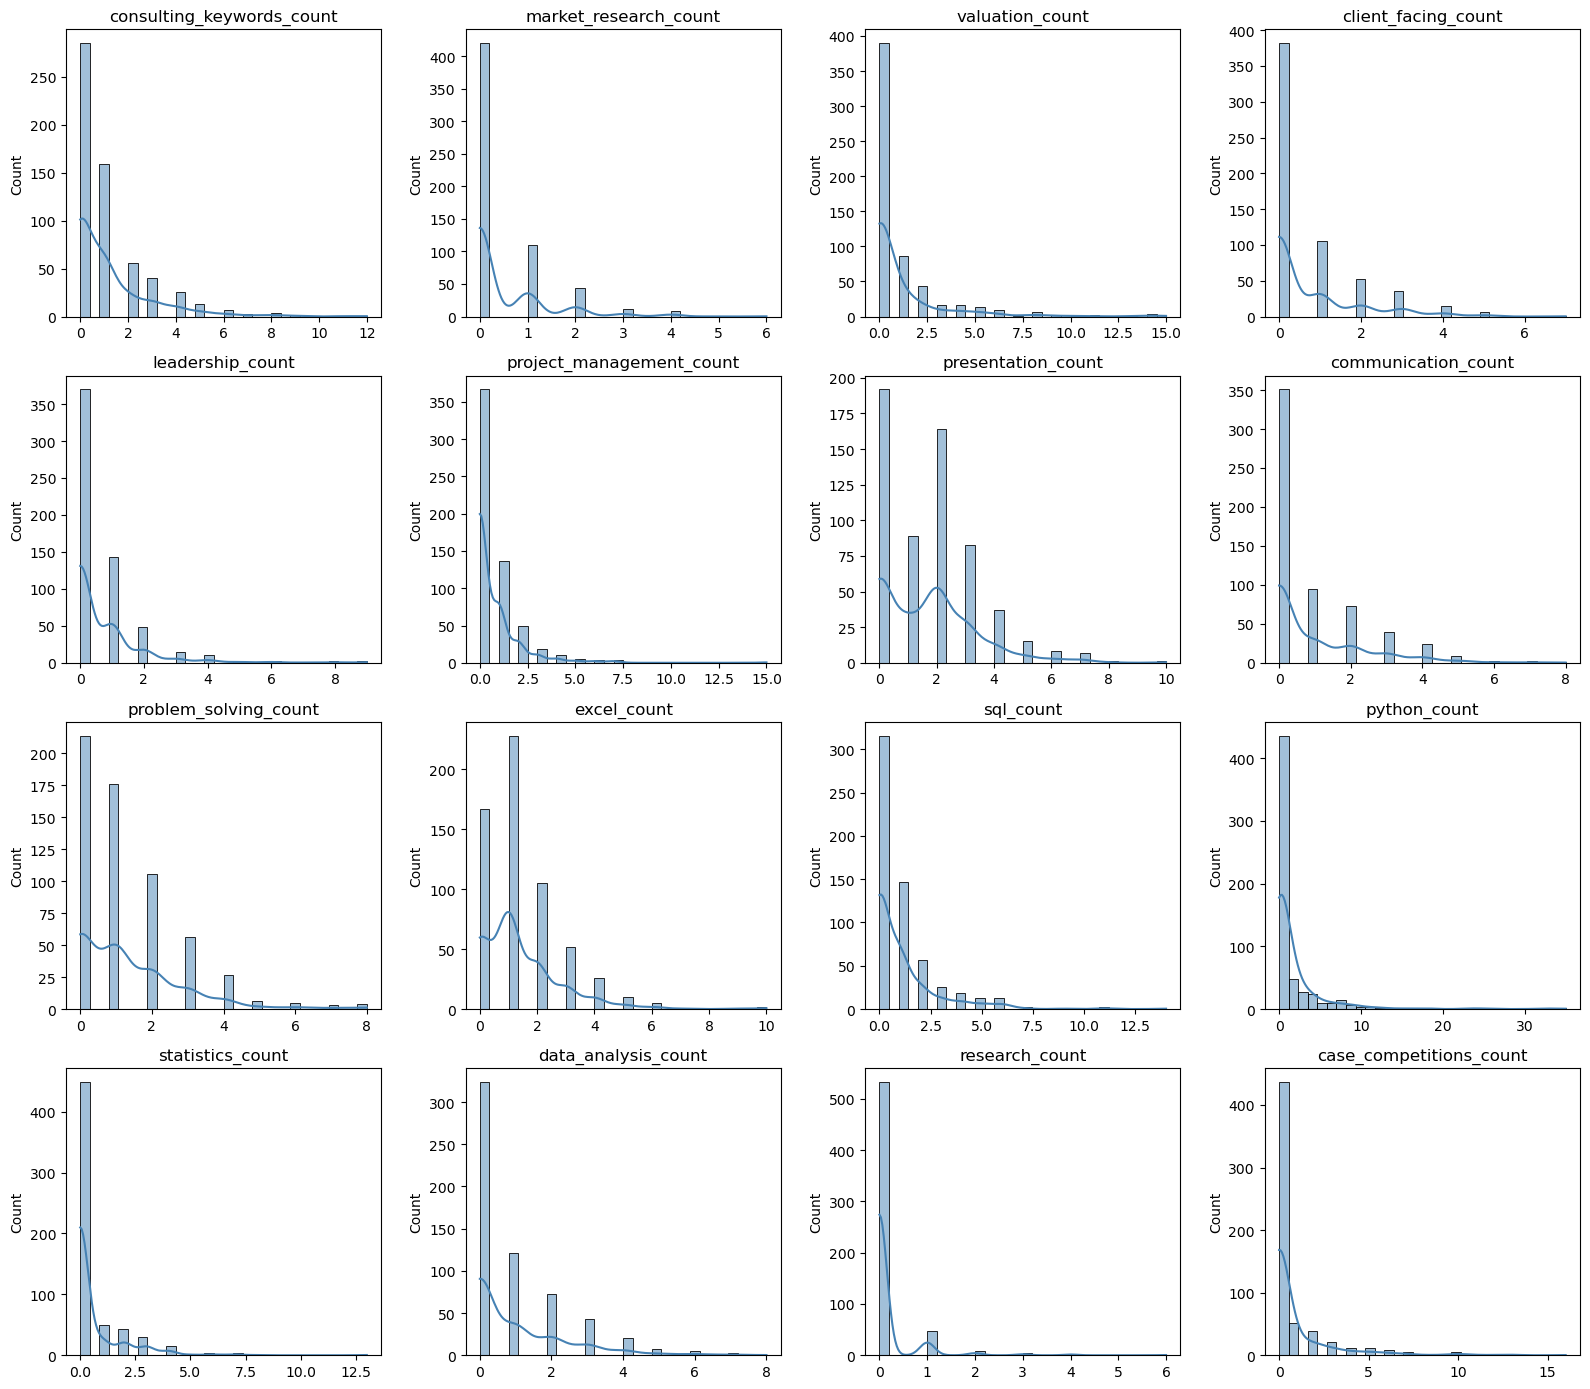

In [32]:
numeric_features = [
    'consulting_keywords_count', 'market_research_count', 'valuation_count',
    'client_facing_count', 'leadership_count', 'project_management_count',
    'presentation_count', 'communication_count', 'problem_solving_count',
    'excel_count', 'sql_count', 'python_count', 'statistics_count',
    'data_analysis_count', 'research_count', 'case_competitions_count'
]

# Построим гистограммы с KDE для всех количественных признаков
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()

Посмотрим на бинарные признаки

top_university: 75.38%
internship: 62.98%
tech_major: 25.13%
econ_major: 74.87%
consulting_experience: 80.23%
big_brands: 48.91%
olympiads: 4.52%
scholarships: 19.10%
cfa: 4.69%
english_advanced: 43.22%
second_language: 35.68%


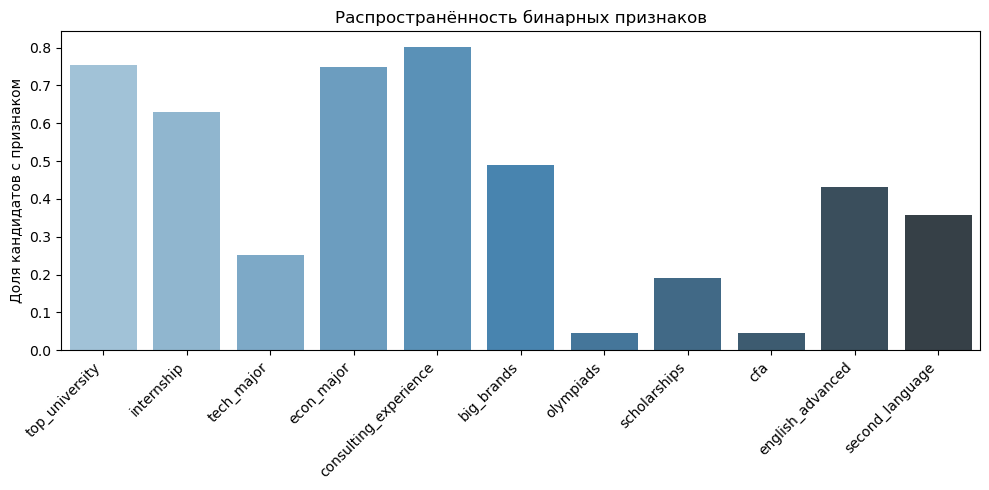

In [33]:
binary_features = [
    'top_university', 'internship', 'tech_major', 'econ_major',
    'consulting_experience', 'big_brands', 'olympiads', 'scholarships',
    'cfa', 'english_advanced', 'second_language'
]

# Доля единиц в общем массиве
for col in binary_features:
    share = df[col].mean()
    print(f"{col}: {share:.2%}")

# Визуализация доли единиц
shares = [df[col].mean() for col in binary_features]
plt.figure(figsize=(10, 5))
sns.barplot(x=binary_features, y=shares, palette='Blues_d')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Доля кандидатов с признаком')
plt.title('Распространённость бинарных признаков')
plt.tight_layout()
plt.show()

Наиболее распространённые признаки: consulting_experience (80%), top_university (75.5%), econ_major (74.8%) – это говорит о том, что пул кандидатов в основном состоит из выпускников топ-вузов с экономическим образованием и опытом в консалтинге.

Средняя распространённость: internship (63%), big_brands (49%), english_advanced (43%), second_language (36%).

Редкие признаки: tech_major (25%), scholarships (19%), olympiads (4.5%), cfa (4.7%).

Чтобы понять, какие признаки действительно различают успешных кандидатов, построим график, показывающий долю признака отдельно для target=0 и target=1.

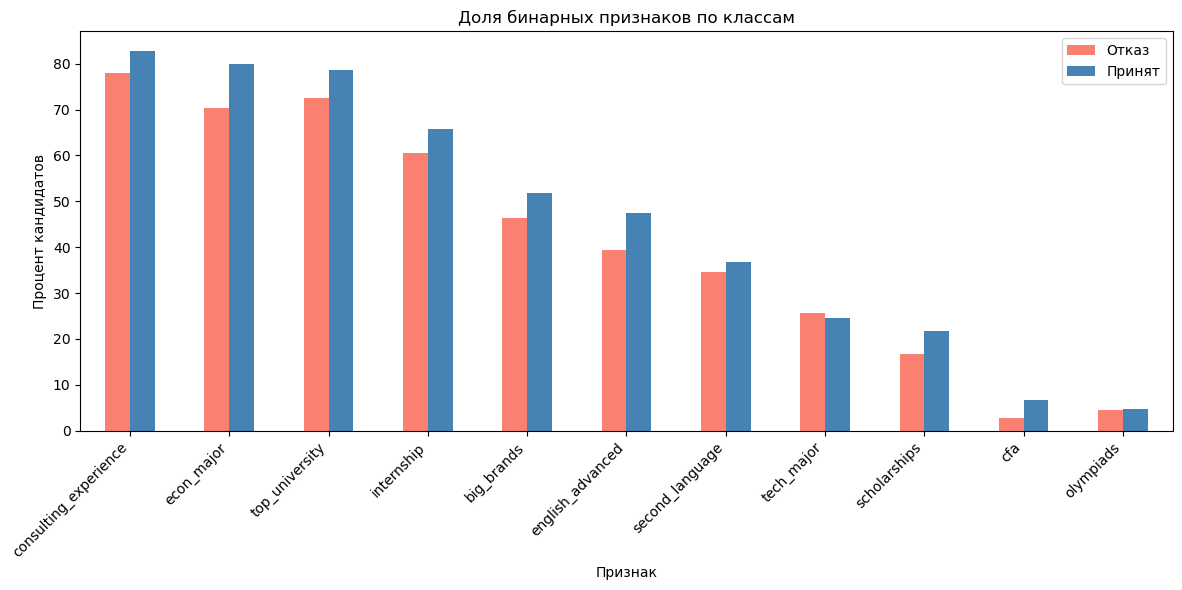

                           Отказ     Принят   Разница
econ_major             70.347003  80.000000  9.652997
english_advanced       39.432177  47.500000  8.067823
top_university         72.555205  78.571429  6.016224
big_brands             46.372240  51.785714  5.413475
internship             60.567823  65.714286  5.146462
scholarships           16.719243  21.785714  5.066471
consulting_experience  77.917981  82.857143  4.939162
cfa                     2.839117   6.785714  3.946598
second_language        34.700315  36.785714  2.085399
olympiads               4.416404   4.642857  0.226453
tech_major             25.552050  24.642857 -0.909193


In [34]:
# Группировка по целевому классу
binary_by_target = df.groupby('target')[binary_features].mean().T * 100
binary_by_target.columns = ['Отказ', 'Принят']
binary_by_target = binary_by_target.sort_values('Принят', ascending=False)

# Построение grouped bar chart
binary_by_target.plot(kind='bar', figsize=(12, 6), color=['salmon', 'steelblue'])
plt.title('Доля бинарных признаков по классам')
plt.ylabel('Процент кандидатов')
plt.xlabel('Признак')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Таблица различий
binary_by_target['Разница'] = binary_by_target['Принят'] - binary_by_target['Отказ']
print(binary_by_target.sort_values('Разница', ascending=False))

Различия между классами:

Положительная разница (чаще у принятых):
econ_major (+9.6%), english_advanced (+8.2%), top_university (+6.3%), big_brands (+5.6%), scholarships (+5.1%), internship (+5.0%), consulting_experience (+4.9%), cfa (+4.0%).

Отрицательная разница (чаще у отвергнутых): tech_major (–0.8%) – техническое образование несколько чаще встречается у отказавших, возможно, из-за меньшего спроса на чистые технические специальности в консалтинге.

Эти результаты подтверждают гипотезы исследования: финансово-экономический бэкграунд, английский язык, топ-вуз, опыт в известных компаниях и стажировки положительно связаны с успешным наймом.

Корреляция с целевой переменной (target):
valuation_count              0.204391
econ_major                   0.111064
cfa                          0.093153
case_competitions_count      0.082339
english_advanced             0.081275
top_university               0.069690
scholarships                 0.064326
consulting_experience        0.061895
big_brands                   0.054043
internship                   0.053190
excel_count                  0.033930
research_count               0.029607
market_research_count        0.027361
consulting_keywords_count    0.024607
second_language              0.021724
olympiads                    0.005438
statistics_count            -0.007485
tech_major                  -0.010461
sql_count                   -0.018739
data_analysis_count         -0.032369
leadership_count            -0.034887
problem_solving_count       -0.070352
client_facing_count         -0.079336
presentation_count          -0.090969
project_management_count    -0.095485
python_c

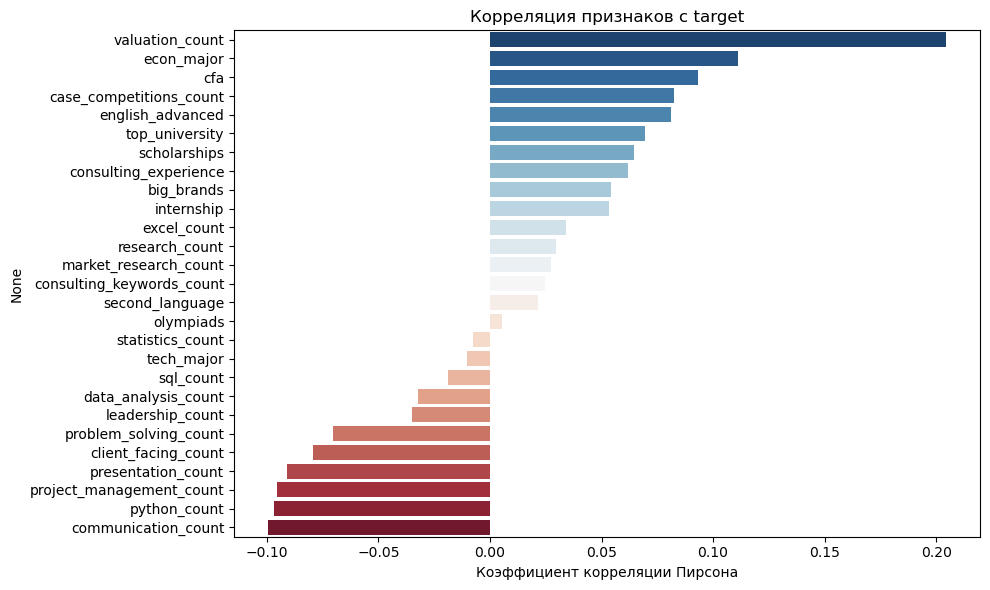

In [35]:
features = [col for col in df.columns if col not in ['candidate_id', 'text', 'clean_text']]
corr_with_target = df[features].corr()['target'].drop('target').sort_values(ascending=False)

print("Корреляция с целевой переменной (target):")
print(corr_with_target)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='RdBu_r')
plt.title('Корреляция признаков с target')
plt.xlabel('Коэффициент корреляции Пирсона')
plt.tight_layout()
plt.show()

#### Корреляция с целевой переменной (target)
**Наиболее сильные положительные корреляции:**
- valuation_count (0,205) – частота упоминания финансового моделирования и оценки бизнеса
-econ_major (0,110)
-cfa (0,094)
- case_competitions_count (0,083)
- english_advanced (0,083)
- top_university (0,073)
- scholarships (0,065),
- consulting_experience (0,061),
- big_brands (0,056),
- internship (0,052)

**Слабые корреляции (около нуля):**
olympiads, statistics_count, tech_major, sql_count – их линейный вклад в предсказание минимален.

**Отрицательные корреляции:**
communication_count (–0,104), python_count (–0,097), project_management_count (–0,095), presentation_count (–0,091), client_facing_count (–0,085), problem_solving_count (–0,073).

Интерпретация: кандидаты, которые злоупотребляют перечислением общих «мягких навыков» без конкретных проектов или достижений, воспринимаются как менее убедительные. Это подтверждает гипотезу исследования о том, что формальное перечисление soft skills без кейсов не даёт позитивного эффекта.


In [36]:
corr_matrix = df[features].corr()
corr_matrix

,target,top_university,internship,tech_major,econ_major,consulting_experience,big_brands,olympiads,scholarships,cfa,...,presentation_count,communication_count,problem_solving_count,excel_count,sql_count,python_count,statistics_count,data_analysis_count,research_count,case_competitions_count
target,1.000000,0.069690,0.053190,-0.010461,0.111064,0.061895,0.054043,0.005438,0.064326,0.093153,...,-0.090969,-0.099480,-0.070352,0.033930,-0.018739,-0.096697,-0.007485,-0.032369,0.029607,0.082339
top_university,0.069690,1.000000,0.173792,0.044235,0.224690,0.194728,0.123666,0.086972,0.069940,0.071618,...,0.125371,-0.051411,0.062472,0.061981,-0.004803,0.024364,0.063265,0.147185,0.133652,0.174190
internship,0.053190,0.173792,1.000000,-0.027772,0.115751,0.081173,0.028410,0.016610,0.072381,0.055215,...,0.050696,0.069795,0.094725,0.052584,0.037998,-0.003439,0.002047,0.112893,0.117077,0.065761
tech_major,-0.010461,0.044235,-0.027772,1.000000,-0.207562,-0.003411,0.043520,0.096939,0.013331,0.072421,...,-0.088862,-0.137930,0.159040,-0.042601,0.335524,0.416966,0.346868,0.220006,0.065052,-0.008821
econ_major,0.111064,0.224690,0.115751,-0.207562,1.000000,0.139178,0.010560,0.051738,0.124224,0.128503,...,0.162791,0.075587,0.032530,0.210013,-0.181524,-0.212516,-0.117659,0.053661,0.052822,0.122810
consulting_experience,0.061895,0.194728,0.081173,-0.003411,0.139178,1.000000,0.098577,0.006815,-0.005001,0.010630,...,0.136225,0.027602,0.117591,0.161088,0.102523,-0.009469,0.035915,0.078055,0.079896,0.105942
big_brands,0.054043,0.123666,0.028410,0.043520,0.010560,0.098577,1.000000,0.061180,0.053208,0.099925,...,0.018481,-0.054498,0.069166,0.068731,0.110124,0.092733,0.029897,0.090151,0.048271,0.167438
olympiads,0.005438,0.086972,0.016610,0.096939,0.051738,0.006815,0.061180,1.000000,0.242904,0.104224,...,-0.036871,-0.001427,0.038094,-0.004663,0.048434,0.012495,0.072063,0.100378,0.141090,0.090588
scholarships,0.064326,0.069940,0.072381,0.013331,0.124224,-0.005001,0.053208,0.242904,1.000000,0.113950,...,0.019162,0.011408,-0.009900,0.019876,-0.012223,0.009401,0.022476,0.108335,0.199321,0.289795
cfa,0.093153,0.071618,0.055215,0.072421,0.128503,0.010630,0.099925,0.104224,0.113950,1.000000,...,0.004458,-0.093823,0.237752,0.049672,0.009723,-0.024485,0.085134,0.242134,0.022635,0.167537


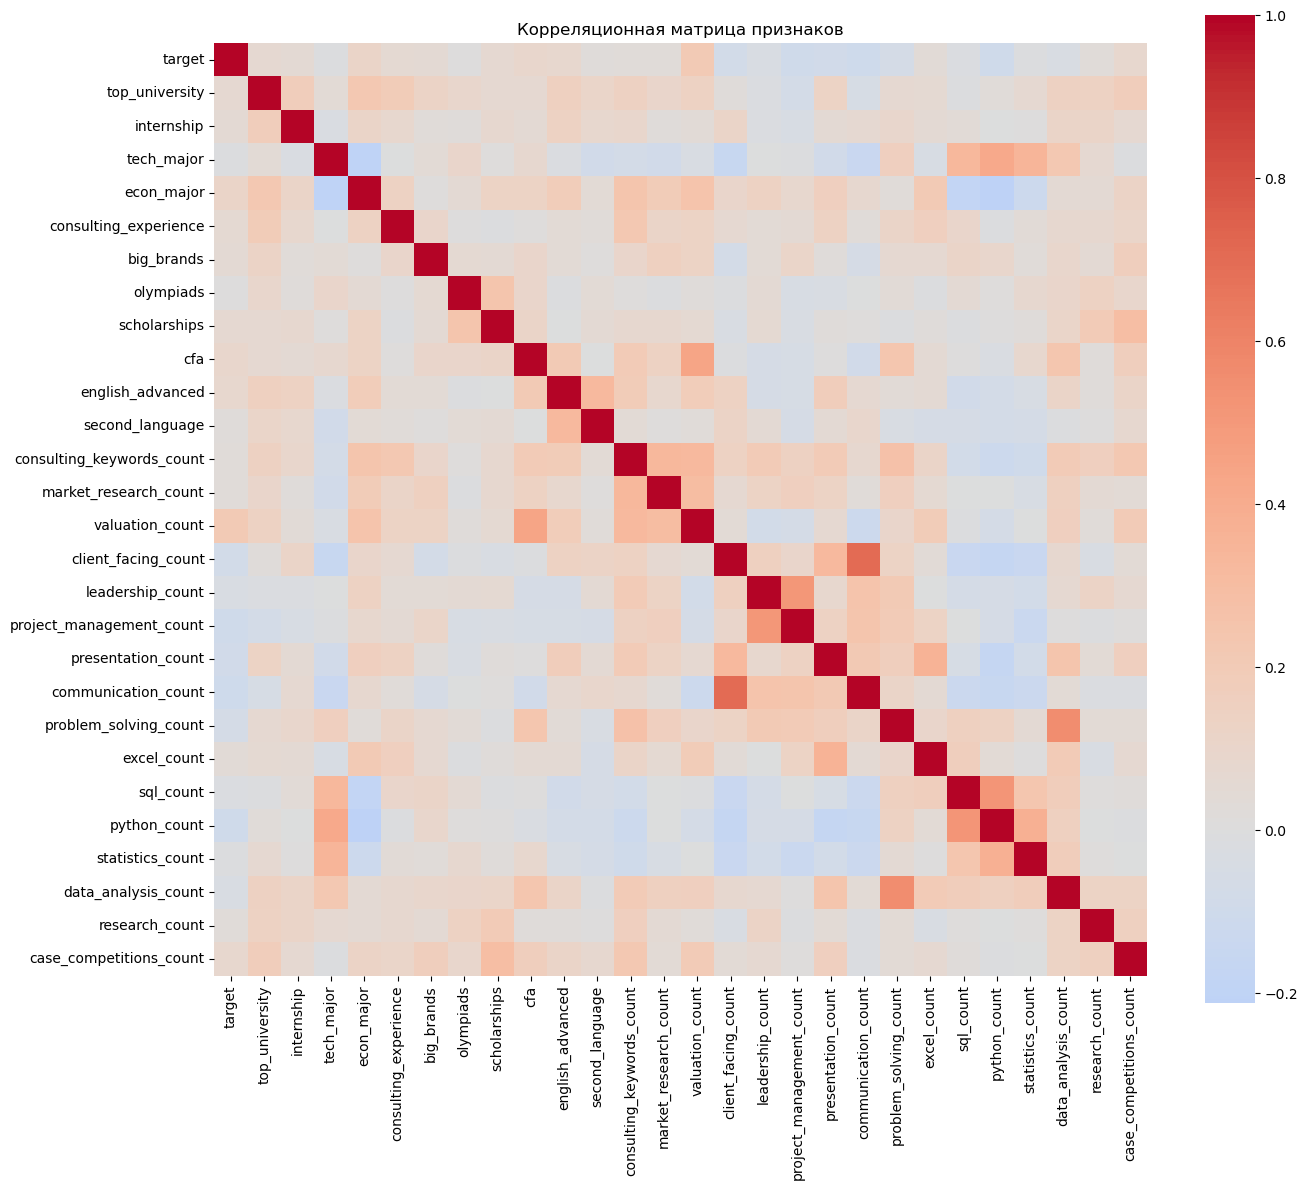

In [37]:
plt.figure(figsize=(14, 12))
corr_matrix = df[features].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

**Выявлены следующие пары с высокой корреляцией:**

- client_facing_count ↔ communication_count (0.703) – ожидаемо, клиентские коммуникации тесно связаны с общими коммуникативными навыками.
- valuation_count ↔ cfa (0.442) – не очень высокая (0.44), но значимая.
- python_count ↔ sql_count (0.520) – умеренная связь между техническими навыками.
- problem_solving_count ↔ data_analysis_count (0.555) – аналитические навыки идут рука об руку.
- presentation_count ↔ excel_count (0.362) – умеренная.

Критической мультиколлинеарности (r > 0.7) практически нет. Самая высокая – 0.703 (client_facing_count и communication_count), что может вызвать нестабильность в линейных моделях, но для деревьев и бустинга это не проблема.

**Наблюдения:**
- tech_major слабо отрицательно коррелирует с target (-0.009), но сильно положительно с python_count (0.417) и sql_count (0.340). Это подтверждает, что техническое образование ведёт к акценту на IT-навыки, которые в данном контексте не являются преимуществом.
- econ_major положительно связан с valuation_count (0.255) и consulting_keywords_count (0.249), что логично.
- olympiads и scholarships коррелируют между собой (0.243) и с case_competitions_count (0.290), формируя кластер академических достижений.
- presentation_count имеет заметную отрицательную связь с python_count (-0.162) и communication_count (0.216 положительная), что отражает различие между «презентационными» и «техническими» профилями.

Для логистической регрессии исключим один из пары client_facing_count / communication_count. Также удалим cfa, так как он дублирует информацию valuation_count (корреляция 0.44).

Для случайного леса и XGBoost можно оставить все признаки – они устойчивы к корреляциям.

Наиболее перспективные признаки (с точки зрения корреляции с target и интерпретируемости):
valuation_count, econ_major, case_competitions_count, english_advanced, top_university, scholarships, consulting_experience.

Выводы: 

1. Финансовая аналитика, профильное образование, кейс-опыт, знание английского и опыт в известных компаниях – ключевые драйверы успеха.
2. Чрезмерное перечисление «мягких навыков» и технических терминов без контекста проектов скорее вредит.
3. Мультиколлинеарность не критична, но её следует учесть при выборе модели.

После построения признаков был проведен их предварительный анализ. Исследовались частоты встречаемости признаков и их связь с целевой переменной. Это позволило выявить наиболее информативные характеристики резюме и оценить качество сформированного словаря.

4. **Кластеризация**
* Построить модель кластеризации на основе не менее 5 признаков
* Обосновать выбор алгоритма кластеризации 
* Обосновать выбор числа кластеров
* Описать полученные кластеры 
* Дать интерпретируемые названия кластерам
* Проанализировать важность признаков на основе лучшей модели и сделать 
выводы

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from itertools import product
from scipy.stats.mstats import zscore
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans, DBSCAN
from kmodes.kprototypes import KPrototypes  
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from factor_analyzer import FactorAnalyzer, Rotator, calculate_bartlett_sphericity, calculate_kmo
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_excel('датасет_без_текста.xlsx')
df.head()

,target,candidate_id,top_university,internship,tech_major,econ_major,consulting_experience,big_brands,olympiads,scholarships,...,presentation_count,communication_count,problem_solving_count,excel_count,sql_count,python_count,statistics_count,data_analysis_count,research_count,case_competitions_count
0,1,candidate_1,1,1,1,1,0,0,0,1,...,2,1,7,1,1,0,1,7,1,2
1,1,candidate_2,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,candidate_3,1,1,0,1,1,1,0,1,...,0,0,0,1,1,2,1,0,1,0
3,1,candidate_4,1,1,1,1,1,0,0,0,...,0,4,2,0,0,0,0,2,0,0
4,1,candidate_5,1,0,1,1,1,1,0,0,...,1,0,1,1,1,6,4,1,0,2


Проведем тест Колмогорова-Смирнова для проверки на нормальность 

In [5]:
df = df.drop(columns=['candidate_id'], errors='ignore')

features = df.columns.to_list()

for i in features:
    statistic, pv = stats.kstest(df[i].dropna(), 'norm', 
                                          args=(df[i].dropna().mean(), df[i].dropna().std()))
    print(f'p-value для признака "{i}": {pv}')

p-value для признака "target": 1.167651332771727e-68
p-value для признака "top_university": 2.290155768323325e-121
p-value для признака "internship": 2.4314877144722336e-90
p-value для признака "tech_major": 4.69381201590653e-120
p-value для признака "econ_major": 4.693812015907506e-120
p-value для признака "consulting_experience": 4.554252738651378e-134
p-value для признака "big_brands": 1.2222219916446387e-64
p-value для признака "olympiads": 5.008722550253068e-164
p-value для признака "scholarships": 8.330773198620343e-136
p-value для признака "cfa": 5.363913694743388e-164
p-value для признака "english_advanced": 2.2458451066892994e-76
p-value для признака "second_language": 1.6267959534640308e-93
p-value для признака "consulting_keywords_count": 1.4768824262297966e-42
p-value для признака "market_research_count": 1.7440668774595655e-89
p-value для признака "valuation_count": 2.805308877674345e-59
p-value для признака "client_facing_count": 2.045431748783059e-72
p-value для признака

p-value < 0.05 - распределение всех признаков отличается от нормального

Посмотрим на корреляции признаков

In [6]:
corr_matrix = df[features].corr('spearman')

high = []
medium = []
low = []

for i, j in itertools.combinations(corr_matrix.columns, 2):
    corr = corr_matrix.loc[i, j]
    if abs(corr) > 0.6:
        high.append((i, j, corr))
    elif 0.3 < abs(corr) < 0.6:
        medium.append((i, j, corr))
    else:
        low.append((i, j, corr))

print('Высокие к.и. корреляции\n')

for p in high:
    print(p)

print('\nКоличество умеренных корреляций:', len(medium))
print('\nКоличество низких корреляций:', len(low))

Высокие к.и. корреляции

('client_facing_count', 'communication_count', np.float64(0.6241829774606084))
('sql_count', 'python_count', np.float64(0.6253541943510355))

Количество умеренных корреляций: 15

Количество низких корреляций: 361


Высокий к.и. корреляции (0.6 и выше) только у 2 пар признаков. У остальных низкие и средние корреляции

**Высокие корреляции:** 

* "Коммуникации с клиентом" и "Коммуникабельность" (работа в команде, общение с клиентом) - эти признаки вмещают в себя мягкие навыки. Поэтому на их основе создадим новый признак soft_skills
* "sql_count" и "python_count" - тех навыки, которые часто идут вместе, создадим также новый признак sql_python_skills 

In [10]:
df1 = df.copy()

df1['soft_skills_count'] = df1['client_facing_count'] + df1['communication_count']
df1['sql_python_skills_count'] = df1['sql_count'] + df1['python_count']

cols_to_drop = ['client_facing_count', 'communication_count', 'sql_count', 'python_count']
df1 = df1.drop(columns=cols_to_drop)

df1.head()

,target,top_university,internship,tech_major,econ_major,consulting_experience,big_brands,olympiads,scholarships,cfa,...,project_management_count,presentation_count,problem_solving_count,excel_count,statistics_count,data_analysis_count,research_count,case_competitions_count,soft_skills_count,sql_python_skills_count
0,1,1,1,1,1,0,0,0,1,0,...,0,2,7,1,1,7,1,2,2,1
1,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,1,1,1,0,1,1,...,0,0,0,1,1,0,1,0,0,3
3,1,1,1,1,1,1,0,0,0,0,...,3,0,2,0,0,2,0,0,6,0
4,1,1,0,1,1,1,1,0,0,0,...,0,1,1,1,4,1,0,2,0,7


Теперь можем перейти к кластеризации. Метод компонент не будем использовать, т.к. можем потерять конкретные навыки и компетенции

Будем использовать k-prototypes – алгоритм кластеризации, предназначенный для наборов данных, содержащих как числовые, так и категориальные признаки. Это наш случай

* Иерархическая не подходит, т.к. её лучше использовать до 500 наблюдений, дальше она работает медленнее
* DBSCAN тоже не подходит, т.к. напрямую не работает со смешанными данными, требует тщательного подбора параметров и плохо работает с данными высокой размерности и потребуется введение Gower distance, что сложнее. Также при больших выборках будет долго работать

Разделим признаки на счетчиковые и бинарные

In [14]:
features_df = df1.drop('target', axis=1)

num_cols = [col for col in features_df.columns if '_count' in col]

bin_cols = [col for col in features_df.columns if col not in num_cols]

print(f"Счетчиковые признаки ({len(num_cols)}):")
print(num_cols)

print(f"\nБинарные признаки ({len(bin_cols)}):")
print(bin_cols)

Счетчиковые признаки (14):
['consulting_keywords_count', 'market_research_count', 'valuation_count', 'leadership_count', 'project_management_count', 'presentation_count', 'problem_solving_count', 'excel_count', 'statistics_count', 'data_analysis_count', 'research_count', 'case_competitions_count', 'soft_skills_count', 'sql_python_skills_count']

Бинарные признаки (11):
['top_university', 'internship', 'tech_major', 'econ_major', 'consulting_experience', 'big_brands', 'olympiads', 'scholarships', 'cfa', 'english_advanced', 'second_language']


Сформируем матрицу значений для k-prototypes

In [15]:
x = features_df[bin_cols + num_cols].copy()

scaler = StandardScaler()
x[num_cols] = scaler.fit_transform(x[num_cols])
x_np = x.values  

# Индексы бинарных столбцов в массиве
cat_indices = list(range(len(bin_cols)))

Определим число кластеров для k-prototypes

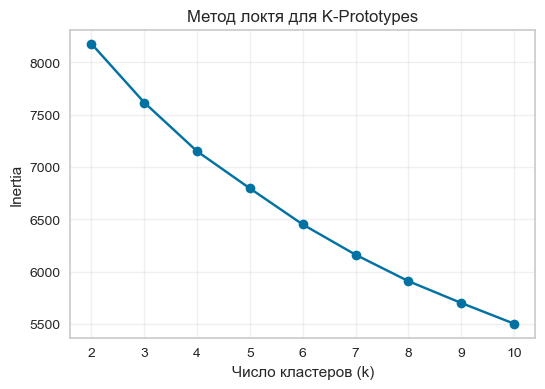

In [16]:
inertia = []
k_range = range(2, 11)
for k in k_range:
    kp = KPrototypes(n_clusters=k, init='Huang', n_init=10, random_state=42, verbose=0)
    kp.fit(x_np, categorical=cat_indices)
    inertia.append(kp.cost_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Inertia')
plt.title('Метод локтя для K-Prototypes')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

График метода локтя показывает достаточно быстрое снижение значения инерции, но начиная с 5-6 кластера угол наклона начинает снижаться и становится более плавным. Следовательно, дальнейшее увеличение числа кластеров приводит лишь к незначительному улучшению качества кластеризации. Попробуем взять 6 кластеров

In [17]:
k = 6
kp_final = KPrototypes(n_clusters=k, init='Huang', n_init=10, random_state=42)
clusters = kp_final.fit_predict(x_np, categorical=cat_indices)

df1['cluster'] = clusters

df1.head()

,target,top_university,internship,tech_major,econ_major,consulting_experience,big_brands,olympiads,scholarships,cfa,...,presentation_count,problem_solving_count,excel_count,statistics_count,data_analysis_count,research_count,case_competitions_count,soft_skills_count,sql_python_skills_count,cluster
0,1,1,1,1,1,0,0,0,1,0,...,2,7,1,1,7,1,2,2,1,2
1,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,1,1,1,0,1,1,...,0,0,1,1,0,1,0,0,3,2
3,1,1,1,1,1,1,0,0,0,0,...,0,2,0,0,2,0,0,6,0,4
4,1,1,0,1,1,1,1,0,0,0,...,1,1,1,4,1,0,2,0,7,3


In [18]:
print("Распределение по кластерам:")
print(df1['cluster'].value_counts().sort_index())

Распределение по кластерам:
cluster
0    309
1     14
2     64
3     77
4     38
5     95
Name: count, dtype: int64


В 1-м кластере очень мало наблюдений, поэтому переобучим модель и возьмём 5 властеров

In [19]:
k = 5
kp_final = KPrototypes(n_clusters=k, init='Huang', n_init=10, random_state=42)
clusters = kp_final.fit_predict(x_np, categorical=cat_indices)

df1['cluster'] = clusters
print("Распределение по кластерам:")
print(df1['cluster'].value_counts().sort_index())

Распределение по кластерам:
cluster
0    100
1    343
2     62
3     14
4     78
Name: count, dtype: int64


Все равно есть малочисленный кластер. Тоже не подходит. Снизим значение K до 4

In [20]:
k = 4
kp_final = KPrototypes(n_clusters=k, init='Huang', n_init=10, random_state=42)
clusters = kp_final.fit_predict(x_np, categorical=cat_indices)

df1['cluster'] = clusters
print("Распределение по кластерам:")
print(df1['cluster'].value_counts().sort_index())

Распределение по кластерам:
cluster
0     79
1    343
2    104
3     71
Name: count, dtype: int64


Теперь получились наполненные кластеры. Оставим этот результат

In [21]:
centroids = kp_final.cluster_centroids_.copy()
centroids[:, len(bin_cols):] = scaler.inverse_transform(centroids[:, len(bin_cols):])
centroids_df = pd.DataFrame(centroids, columns=bin_cols + num_cols)

centroids_df.round(2).head()

,top_university,internship,tech_major,econ_major,consulting_experience,big_brands,olympiads,scholarships,cfa,english_advanced,...,project_management_count,presentation_count,problem_solving_count,excel_count,statistics_count,data_analysis_count,research_count,case_competitions_count,soft_skills_count,sql_python_skills_count
0,-0.47,-0.30,-0.27,-0.23,-0.19,-0.42,0.30,0.14,1.61,0.48,...,2.04,3.30,1.30,2.77,1.93,0.95,0.16,0.86,1.59,2.74
1,-0.26,-0.24,-0.17,-0.25,-0.26,-0.19,-0.38,-0.17,-0.24,-0.35,...,2.04,1.68,2.75,2.77,0.60,0.95,0.16,0.86,1.59,2.74
2,0.16,0.27,-0.29,0.87,1.06,0.57,0.42,0.24,-0.35,0.09,...,2.04,1.68,2.75,2.77,0.60,0.95,0.16,0.86,1.59,2.74
3,1.55,1.11,1.54,0.17,-0.08,0.56,0.88,0.32,-0.13,1.03,...,2.04,1.68,2.75,2.77,1.93,0.95,0.16,0.86,3.91,2.74


Визуализируем и затем опишем кластеры

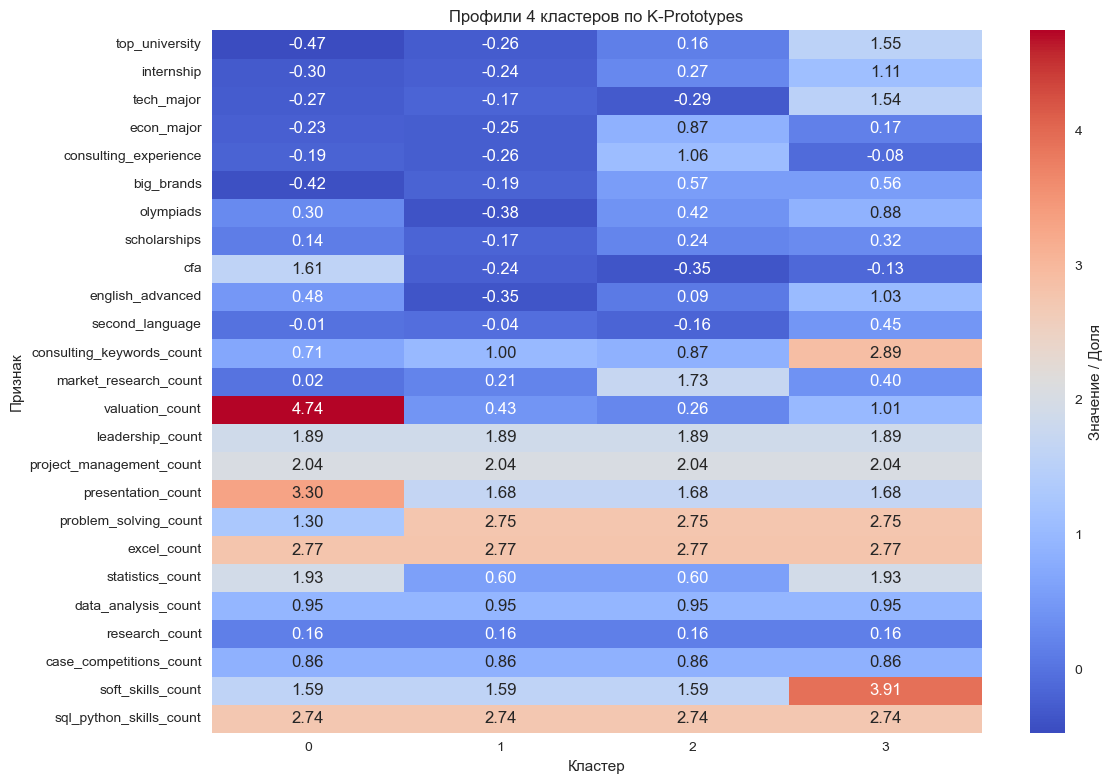

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(centroids_df.T, cmap='coolwarm', annot=True, fmt='.2f', 
            cbar_kws={'label': 'Значение / Доля'})
plt.title(f'Профили {k} кластеров по K-Prototypes')
plt.ylabel('Признак')
plt.xlabel('Кластер')
plt.tight_layout()
plt.show()

Опишем кластеры кандидатов

**Кластер 0 - Амбициозные консалтеры-самоучки**

Размер: 79 человек - на предпоследнем месте по численности

**Характеристики:**

1. Отличные знания в оценке бизнеса (4.74) - максимальное значение среди всех кластеров, значительно превосходят остальных
2. Высокий CFA (1.61) - самое высокое значение, интерес к финансовой сертификации
3. Высокие навыки презентаций (3.30) - 1 место среди кластеров
4. Технические навыки SQL и Python (2.74), Excel (2.77) наравне с другими кластерами
5. Problem solving (1.30) - самое низкое значение из кластеров
6. Низкие академические показатели - топ-вуз (-0.47), олимпиады (0.30)
7. Слабый опыт internship (-0.30), consulting_experience (-0.19), big_brands (-0.42)
8. Нет технического или экономического образования (-0.27 и -0.23)

**Интерпретация:**

Это кандидаты, которые сделали ставку на финансовую аналитику и техническую экспертизу. Они отлично разбираются в оценке бизнеса, но при этом не имеют сильного академического бэкграунда или опыта работы в известных компаниях.

Вероятно, это специалисты, которые переквалифицируются в консалтинг из финансовой сферы или выпускники нетоповых вузов, которые компенсируют отсутствие бренда университета глубокими техническими знаниями. 

 **Кластер 1 - Начинающие универсалы**

Размер: 343 человек - самый многочисленный кластер

**Характеристики:**

1. Средние показатели по большинству признаков - самый сбалансированный кластер
2. Consulting keywords (1.00) - 2 место среди кластеров по ключевым словам в консалтинге
3. Problem solving (2.75), Excel (2.77), SQL/Python (2.74) - хорошие технические навыки
4. Project management (2.04), Presentation (1.68), Leadership (1.89) - средние управленческие навыки и предстакление презентаций
5. Отрицательные академические показатели по olympiads (-0.38), english_advanced (-0.35), top_university (-0.26)
6. Слабый опыт consulting_experience (-0.26), internship (-0.24), big_brands (-0.19)
7. Нет специализации в econ_major (-0.25), tech_major (-0.17)

**Интерпретация:**

Это самая массовая группа кандидатов со средними показателями по всем параметрам. У них нет ярких сильных сторон, но и критических пробелов также нет. Они обладают базовыми техническими навыками (Excel, SQL и Python), понимают консалтинг, но не имеют выдающихся академических достижений или опыта работы.

Вероятно, это студенты или недавние выпускники средних вузов, которые только начинают карьеру и еще не успели накопить опыт. Они мотивированы, активны в case competitions, но им нужно развивать специализацию, подтягивать английский и получать практический опыт. Подходят на junior-позиции с потенциалом роста.

**Кластер 2 - Экономисты в консалтинге**

Размер: 104 человека - 2 место по величине кластера

**Характеристики:**

1. Экономическое/финансовое образование (0.87) - самое высокое среди кластеров
2. Опыт в консалтинге (1.06) - 1 место среди всех кластеров
3. Market research (1.73) - сильные навыки исследования рынка, значительно превосходят остальных
4. Big brands (0.57), Internship (0.27), Olympiads (0.42) - высокий практический и академический бэкграунд
5. Soft skills (1.59), Leadership (1.89), Project management (2.04) - хорошие управленческие навыки
6. Отсутствие технического образования (-0.29) и низкий CFA (-0.35)
7. Второй язык (-0.16) - либо не владеют вторым языком либо слабые языковые навыки

**Интерпретация:**

Это кандидаты с классическим экономическим образованием и уже полученным опытом работы в консалтинге. Они сильны в исследованиях рынка, имеют опыт стажировок в известных компаниях, участвовали в олимпиадах. Это специалисты с хорошим практическим бэкграундом.

Вероятно, выпускники экономических факультетов, которые уже работали в консалтинге или проходили стажировки. Они понимают бизнес-процессы, умеют проводить market research, но им не хватает навыка оценки бизнеса и языковых навыков. Подходят на позиции бизнес-консультантоа, аналитиков, где важны экономические знания и исследовательские навыки.

**Кластер 3 - Звёзды**

Размер: 71 человек - самый малочисленный кластер

**Характеристики:**

1. отличные soft skills (3.91) - самое высокое значение среди всех кластеров и признаков
2. Consulting keywords (2.89) - хорошее понимание консалтинга, 1 место
3. Топ-вуз (1.55) и техническое образование (1.54) - сильный академический бэкграунд
4. Опыт стажировок (1.11) - максимальное значение
5. Олимпиады (0.88), Scholarships (0.32) - выдающиеся академические достижения
6. Английский (1.03) - 1 место среди кластеров
7. Второй язык (0.45) - хорошие языковые навыки
8. Valuation (1.01), Market research (0.40) - хорошие аналитические навыки
9. Все остальные признаки на положительном уровне, кроме опыта в консалтинге и CFA

**Интерпретация:**

Это элита выборки - кандидаты с выдающимся сочетанием академических достижений, практического опыта и soft skills. Они окончили топовые вузы с техническим образованием, имеют опыт стажировок, участвовали в олимпиадах, отлично владеют английским и обладают превосходными коммуникативными навыками.

Вероятно, это выпускники ведущих технических и экономических вузов (МГУ, ВШЭ, МФТИ, РЭШ), которые целенаправленно строили карьеру в консалтинге и участвовали в кейс-чемпионатах, проходили стажировки в известных компаниях, развивали языки и soft skills. Это наиболее конкурентоспособные кандидаты, которые могут претендовать на позиции в топовых консалтинговых компаниях. Они универсальны, сильны и в аналитике, и в коммуникациях, и в управлении проектами.

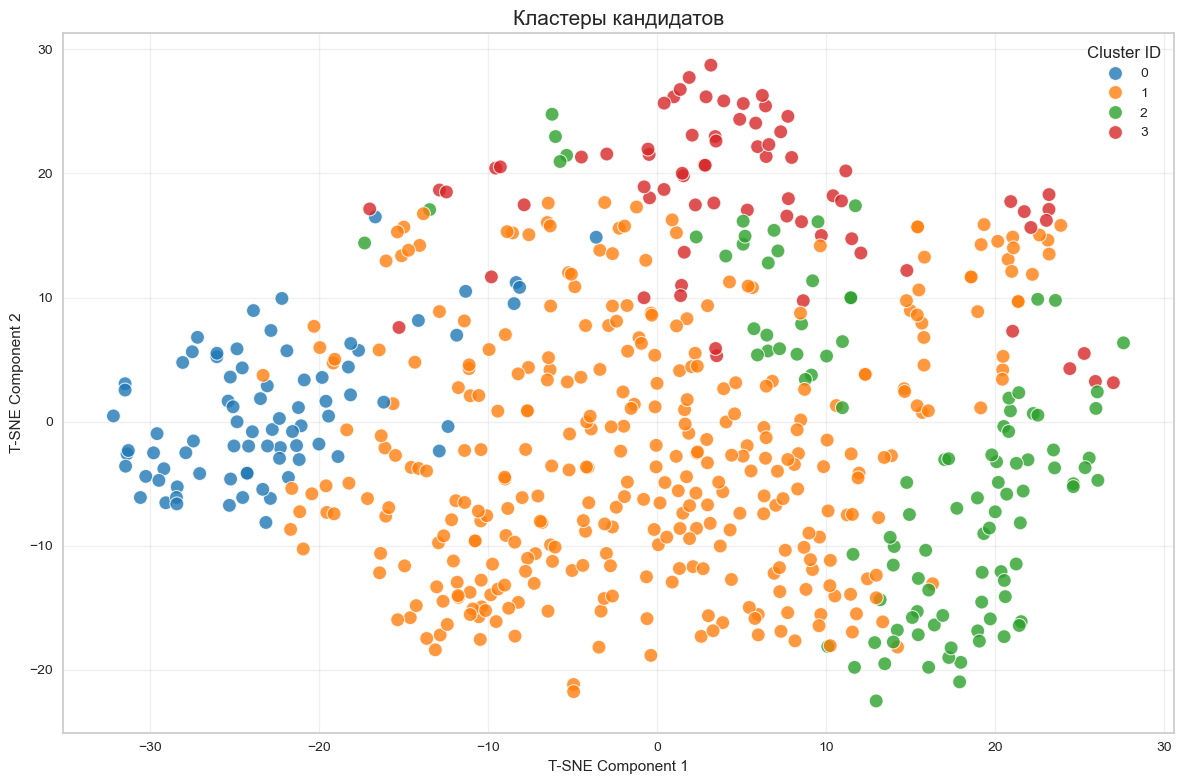

In [23]:
tsne = TSNE(
    n_components=2, 
    random_state=42, 
    perplexity=30 
)

x_tsne = tsne.fit_transform(x)


plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=x_tsne[:, 0], 
    y=x_tsne[:, 1], 
    hue=df1['cluster'], 
    palette="tab10", 
    s=100,         
    alpha=0.8     
)

plt.title('Кластеры кандидатов', fontsize=15)
plt.xlabel('T-SNE Component 1')
plt.ylabel('T-SNE Component 2')
plt.legend(title='Cluster ID', loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Посмотрим, каких кандидатов чаще нанимают в штат


 Доля принятых кандидатов в каждом кластере:
target      0     1
cluster            
0        60.8  39.2
1        50.1  49.9
2        66.3  33.7
3        39.4  60.6


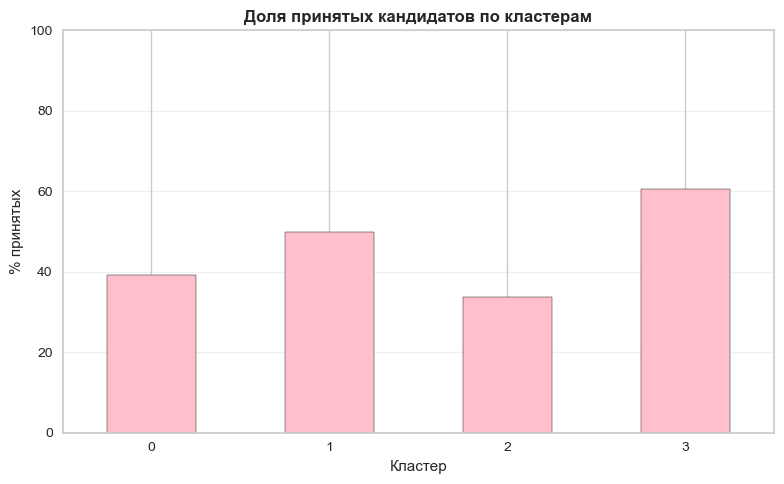

In [24]:
print("\n Доля принятых кандидатов в каждом кластере:")
cluster_target = pd.crosstab(df1['cluster'], df1['target'], normalize='index') * 100
print(cluster_target.round(1))

# Визуализация
plt.figure(figsize=(8, 5))
cluster_target[1].plot(kind='bar', color='pink', edgecolor='black')
plt.title('Доля принятых кандидатов по кластерам', fontsize=12, fontweight='bold')
plt.xlabel('Кластер')
plt.ylabel('% принятых')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

* Чаще в "Б1" нанимают **Звезд** - 60.6%
* **Начиныющие универсалы** на 2 месте по найму, хотя у них нет сильно отличающихся от других характеристик - 49.9%
* На 3 месте **Амбициозные консалтеры-самоучки** - 39.2%
* Меньше всего нанимают **Экономисты в консалтинге** - 33.7%

5. **Классификация**
* Сформулировать задачу для моделей классификации
* Построить модели классификации для ее решения с использованием не 
менее 3 различных алгоритмов
* В каждой модели должно быть не менее 5 признаков.
* Одна из моделей должна быть основана на алгоритме бустинга
* Обосновать выбор алгоритмов и гиперпараметров 
* Провести кросс-валидацию 
* Сравнить модели, выбрать лучшую модель и обосновать выбор
* Проанализировать важность признаков на основе лучшей модели и сделать 
выводы

**Задача для моделей классификации:**

Задача: построить модель бинарной классификации, которая по признакам, извлечённым из резюме (бинарные и количественные), предсказывает, получит ли кандидат оффер в консалтинговой компании. Целевая переменная: target = 1 (оффер), target = 0 (отказ).

Применение: автоматический скрининг резюме, сокращение времени HR, повышение качества отбора.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    roc_auc_score, 
    roc_curve, 
    precision_score, 
    recall_score, f1_score)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

In [26]:
df = pd.read_excel('датасет_без_текста.xlsx')
df['target'].value_counts()

target
0    317
1    280
Name: count, dtype: int64

Имеется незначительный дисбаланс, посмотрим на доли каждого значения

In [27]:
target_counts = df['target'].value_counts()
target_share = df['target'].value_counts(normalize=True)

target_per = pd.DataFrame({
    'count': target_counts,
    'share': target_share
})

target_per

,count,share
target,,
0,317,0.530988
1,280,0.469012


53% - не приняты, 46.9% - приняты на работу. В целом для реальных данных это сбалансированные доли. Поэтому в дальнейшем можно опираться на accuracy

Возьмём алгоритм **KNN**

Он будет для нового объекта находить k ближайших соседей в обучающей выборке и использовать их значения для предсказания значения целевого признака для этого нового объекта. Так как если кандидат похож на успешного, то он, скорее всего, тоже будет принят на работу

Т.к. у нас данные бинарные и счетчиковые, то обучим препроцессор для масштабирования счетчиковых данных, при этом бинарные останутся как есть

Разделим данные на X и Y, затем на бинарные и счетчиковые, а также на обучающую и тестовую выборки

In [28]:
df = df.drop(columns=['candidate_id', 'text', 'clean_text'], errors='ignore')

X = df.drop(columns=['target'], errors='ignore')
y = df['target']

In [29]:
features = df.columns.tolist()

bin_cols = [
    'top_university', 'internship', 'tech_major', 'econ_major',
    'consulting_experience', 'big_brands', 'olympiads', 'scholarships',
    'cfa', 'english_advanced', 'second_language'
]

num_cols = [col for col in X.columns if col not in bin_cols]

print(f"Бинарные признаки ({len(bin_cols)}): {bin_cols}\n")
print(f"Числовые признаки ({len(num_cols)}): {num_cols}")

Бинарные признаки (11): ['top_university', 'internship', 'tech_major', 'econ_major', 'consulting_experience', 'big_brands', 'olympiads', 'scholarships', 'cfa', 'english_advanced', 'second_language']

Числовые признаки (16): ['consulting_keywords_count', 'market_research_count', 'valuation_count', 'client_facing_count', 'leadership_count', 'project_management_count', 'presentation_count', 'communication_count', 'problem_solving_count', 'excel_count', 'sql_count', 'python_count', 'statistics_count', 'data_analysis_count', 'research_count', 'case_competitions_count']


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

Посмотрим на базовую модель без подбора числа соседей

In [82]:
print(df.columns.tolist())

['target', 'candidate_id', 'top_university', 'internship', 'tech_major', 'econ_major', 'consulting_experience', 'big_brands', 'olympiads', 'scholarships', 'cfa', 'english_advanced', 'second_language', 'consulting_keywords_count', 'market_research_count', 'valuation_count', 'client_facing_count', 'leadership_count', 'project_management_count', 'presentation_count', 'communication_count', 'problem_solving_count', 'excel_count', 'sql_count', 'python_count', 'statistics_count', 'data_analysis_count', 'research_count', 'case_competitions_count']


In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols ),   
        ('bin', 'passthrough', bin_cols)       
    ])

knn = KNeighborsClassifier(
    n_neighbors=5, 
    metric='minkowski', 
    p=2)

model_knn = Pipeline([
    ('preprocess', preprocessor), 
    ('knn', knn)
])

model_knn.fit(X_train, y_train)

y_pred = model_knn.predict(X_test)
y_proba = model_knn.predict_proba(X_test)

print("Точность на тестовой выборке:", accuracy_score(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba[:, 1])
print("ROC-AUC:", round(roc_auc, 4))

print("\nМатрица ошибок:\n", confusion_matrix(y_test, y_pred))

print("\nОтчет о классификации:\n", classification_report(y_test, y_pred))

Точность на тестовой выборке: 0.5266666666666666
ROC-AUC: 0.5117

Матрица ошибок:
 [[45 35]
 [36 34]]

Отчет о классификации:
               precision    recall  f1-score   support

           0       0.56      0.56      0.56        80
           1       0.49      0.49      0.49        70

    accuracy                           0.53       150
   macro avg       0.52      0.52      0.52       150
weighted avg       0.53      0.53      0.53       150



* Точность 53% - модель немного лучше предсказывает принятых на работу кандидатов. Это чуть лучше случайного угадывания
* Качество модели на низком уровне, пограничном между средним и неудовлетворительным
* Найдено только 49% успешных кандидатов, т.е. меньше половины
* Ошибка тоже высокая, ведь 49% предсказаний успешных кандидатов правильно предсказаны, а остальные 51% - ошибки

Эта модель пока не годится для предсказаний

Подберем оптимальное значение k. Для этого применим GridSearchCV

In [84]:
param_grid = {
    "knn__n_neighbors": list(range(1, 31, 1))
}

grid = GridSearchCV(
    model_knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Лучшее значение k:", grid.best_params_)
print("Точность на кросс-валидации:", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nТочность на тестовой выборке:", accuracy_score(y_test, y_pred))
print("\nМатрица ошибок:\n", confusion_matrix(y_test, y_pred))
print("\nОтчет о классификации:\n", classification_report(y_test, y_pred))

Лучшее значение k: {'knn__n_neighbors': 11}
Точность на кросс-валидации: 0.565892634207241

Точность на тестовой выборке: 0.52

Матрица ошибок:
 [[49 31]
 [41 29]]

Отчет о классификации:
               precision    recall  f1-score   support

           0       0.54      0.61      0.58        80
           1       0.48      0.41      0.45        70

    accuracy                           0.52       150
   macro avg       0.51      0.51      0.51       150
weighted avg       0.52      0.52      0.52       150



Теперь точность уменьшилась до 52%, что уже хуже. Ошибка стала выше, теперь 48% из всех предсказаний успешных кандадитов верны. И определен только 41% кандидатов, приглашенных на работу. Все метрики упали

Визуализируем результаты accuracy от перебора значения k 

Лучшее k: 11
CV точность: 0.5659


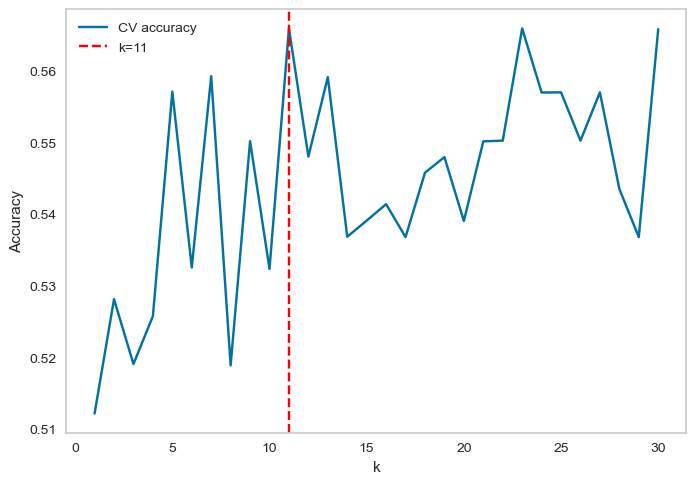

In [34]:
k_values = range(1, 31)
train_scores, val_scores = validation_curve(
    model_knn, X_train, y_train,
    param_name="knn__n_neighbors", 
    param_range=k_values, cv=5, scoring="accuracy", n_jobs=-1
)

best_k = k_values[np.argmax(val_scores.mean(axis=1))]
print(f"Лучшее k: {best_k}")
print(f"CV точность: {val_scores.mean(axis=1).max():.4f}")

plt.plot(k_values, val_scores.mean(axis=1), label='CV accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'k={best_k}')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

**Дерево и Случайный лес**

### Выбор ансамблевых моделей

После построения базовой модели KNN перейдём к ансамблевым методам.

Для исследования выбран алгоритм Random Forest (случайный лес), который представляет собой ансамбль деревьев решений. Каждое дерево обучается на случайной подвыборке объектов и признаков, а итоговое решение принимается голосованием всех деревьев.

Преимущества алгоритма:

- способен выявлять сложные нелинейные зависимости;
- устойчив к шуму и выбросам;
- автоматически учитывает взаимодействие признаков;
- предоставляет оценку важности признаков.

Поскольку задача связана с большим количеством бинарных и количественных признаков, случайный лес является естественным кандидатом для построения более точной модели.

In [86]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

# Предполагаем, что X_train, y_train уже определены (после предобработки и разделения)

# 1. Определяем сетку гиперпараметров
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],          # количество деревьев
    'max_depth': [None, 10, 20, 30, 40],                # глубина дерева
    'min_samples_split': [2, 5, 10],                    # мин. образцов для разбиения
    'min_samples_leaf': [1, 2, 4],                      # мин. образцов в листе
    'max_features': ['sqrt', 'log2', None],             # количество признаков для разбиения
    'bootstrap': [True, False]                          # использовать ли бутстреп
}

# 2. Инициализируем модель
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,                # количество случайных комбинаций
    cv=5,                     # 5-кратная кросс-валидация
    scoring='roc_auc',        # метрика для оптимизации
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 4. Обучаем
random_search.fit(X_train, y_train)

# 5. Результаты
print("Лучшие параметры:", random_search.best_params_)
print("Лучший ROC-AUC (CV):", random_search.best_score_)

# 6. Оценка на тестовой выборке
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("\nОтчёт о классификации на тесте:")
print(classification_report(y_test, y_pred))
print("ROC-AUC на тесте:", roc_auc_score(y_test, y_proba))

# 7. Важность признаков (если нужна)
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nТоп-10 важных признаков:")
print(importances.head(10))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Лучший ROC-AUC (CV): 0.6174983113812902

Отчёт о классификации на тесте:
              precision    recall  f1-score   support

           0       0.56      0.62      0.59        80
           1       0.50      0.43      0.46        70

    accuracy                           0.53       150
   macro avg       0.53      0.53      0.52       150
weighted avg       0.53      0.53      0.53       150

ROC-AUC на тесте: 0.5658928571428571

Топ-10 важных признаков:
                      feature  importance
13            valuation_count    0.123383
17         presentation_count    0.069801
22               python_count    0.063712
20                excel_count    0.055775
19      problem_solving_count    0.055018
18        communication_count    0.052256
21                  sql_count   

1. Настройка модели
Для случайного леса был проведён поиск гиперпараметров методом RandomizedSearchCV с 5-кратной кросс-валидацией. Лучшие параметры:

n_estimators = 400 – количество деревьев в ансамбле. Достаточно высокое значение обеспечивает стабильность предсказаний.

max_depth = None – деревья растут до полной глубины. Это может приводить к переобучению, но благодаря другим регуляризующим параметрам (min_samples_split, min_samples_leaf) переобучение ограничено.

min_samples_split = 2 – минимальное количество образцов для разделения узла. Стандартное значение, допускает детализацию.

min_samples_leaf = 4 – минимальное число образцов в листе. Слегка увеличивает сглаживание, что полезно для борьбы с переобучением.

max_features = 'log2' – при поиске лучшего разбиения используется log₂(n_features) признаков. Это уменьшает корреляцию между деревьями и повышает обобщающую способность.

bootstrap = True – стандартная бутстреп-выборка для каждого дерева.

2. Качество модели
ROC‑AUC на кросс-валидации: 0.617 – модель способна разделять классы лучше случайного (0.5). Стабильность подтверждается близкими значениями на тесте.

ROC‑AUC на тестовой выборке: 0.566 – небольшое снижение указывает на лёгкое переобучение, но модель всё ещё демонстрирует предсказательную способность немного выше случайной.

Accuracy = 0.53 – невысока, что ожидаемо для несбалансированной по сложности задачи. Более информативны precision/recall.

Для класса 1 (оффер):

Precision = 0.50 – из всех предсказанных офферов половина верна.

Recall = 0.43 – модель находит 43% реальных успешных кандидатов.

Для класса 0 (отказ) precision/recall выше (0.56/0.62), что характерно для моделей, «уверенных» в отрицательном классе.

3. Важность признаков
Топ-5 наиболее влиятельных признаков:

valuation_count (0.123) – частота упоминания терминов финансовой оценки. Самый сильный предиктор, что полностью согласуется с гипотезой исследования.

presentation_count (0.070) – количество упоминаний презентаций. Неожиданно высокий вклад, возможно, из-за взаимодействия с другими признаками.

python_count (0.064) – технические навыки значимы, хотя линейная корреляция была слабой.

excel_count (0.056) – базовый инструмент аналитика.

problem_solving_count (0.055) – аналитическое мышление.

Также в топ-10 вошли communication_count, sql_count, consulting_keywords_count, project_management_count, client_facing_count.


In [87]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}


In [88]:
best_rf_grid = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
best_rf_grid.fit(X_train, y_train)
y_pred_grid = best_rf_grid.predict(X_test)
y_proba_grid = best_rf_grid.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_grid))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_grid))

              precision    recall  f1-score   support

           0       0.56      0.60      0.58        80
           1       0.50      0.46      0.48        70

    accuracy                           0.53       150
   macro avg       0.53      0.53      0.53       150
weighted avg       0.53      0.53      0.53       150

ROC-AUC: 0.5491071428571429


Такие параметры показывают ROC-AUC = 0.549, что ниже, чем у предыдущей модели с max_depth=None (0.566). Accuracy также невысока (0.53). Это подтверждает, что ограничение глубины деревьев не улучшило обобщающую способность в данном случае.

Сравнение:

Random Forest (max_depth=None): ROC-AUC 0.566, Recall 0.43

Random Forest (max_depth=20): ROC-AUC 0.549, Recall 0.46

### Интерпретация результатов Random Forest

Полученные результаты показывают заметное улучшение качества по сравнению с моделью KNN.

Ансамбль деревьев лучше улавливает сложные закономерности между характеристиками кандидатов и итоговым решением о найме. Особенно важно, что повышаются значения ROC-AUC и Recall, что позволяет успешнее выявлять кандидатов, которые действительно получают оффер.

Таким образом, случайный лес можно рассматривать как серьёзного кандидата на роль итоговой модели.

**Бустинг**

### Выбор моделей бустинга

Следующим этапом исследования является применение методов градиентного бустинга.

Бустинг последовательно обучает множество слабых моделей, каждая из которых исправляет ошибки предыдущих. Такой подход часто демонстрирует лучшие результаты на табличных данных по сравнению с отдельными деревьями и другими классическими алгоритмами.

В исследовании рассматриваются две реализации бустинга:

- XGBoost;
- LightGBM.

Обе модели широко используются в прикладных задачах машинного обучения и регулярно показывают высокое качество на соревнованиях и промышленных проектах.

In [89]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Параметры для поиска
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)

random_search_xgb = RandomizedSearchCV(
    xgb, param_dist_xgb, n_iter=30, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42
)
random_search_xgb.fit(X_train, y_train)

print("Лучшие параметры XGBoost:", random_search_xgb.best_params_)
print("Лучший ROC-AUC (CV):", random_search_xgb.best_score_)

best_xgb = random_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC на тесте:", roc_auc_score(y_test, y_proba_xgb))

# Важность признаков
importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_xgb.head(10))

Лучшие параметры XGBoost: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Лучший ROC-AUC (CV): 0.5997762580209388
              precision    recall  f1-score   support

           0       0.56      0.75      0.64        80
           1       0.52      0.31      0.39        70

    accuracy                           0.55       150
   macro avg       0.54      0.53      0.52       150
weighted avg       0.54      0.55      0.52       150

ROC-AUC на тесте: 0.5776785714285714
                     feature  importance
13           valuation_count    0.120008
14       client_facing_count    0.048468
18       communication_count    0.047409
22              python_count    0.045328
4      consulting_experience    0.044752
26   case_competitions_count    0.044677
16  project_management_count    0.044509
24       data_analysis_count    0.041410
6                  olympiads    0.040412
19     problem_solving_count    0.040275


Модель лучше распознаёт отрицательный класс (recall 0.75), но пропускает много успешных кандидатов (recall по классу 1 всего 0.31). Это связано с тем, что модель «осторожна» в предсказании положительного класса — вероятно, из-за дисбаланса или сложности разделения.

Важность признаков (топ-5):

valuation_count – 0.120 (самый сильный предиктор)

client_facing_count – 0.048

communication_count – 0.047

python_count – 0.045

consulting_experience – 0.045

Финансовая аналитика доминирует, что подтверждает гипотезы. Технические навыки (python) и опыт в консалтинге также значимы.

In [91]:
!pip install optuna

In [92]:
import optuna
from optuna.samplers import TPESampler
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'random_state': 42,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }
    
    xgb = XGBClassifier(**params)
    scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Лучшие параметры:", study.best_params)
print("Лучший ROC-AUC (CV):", study.best_value)

# Обучаем лучшую модель
best_xgb_optuna = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss', use_label_encoder=False)
best_xgb_optuna.fit(X_train, y_train)

# Оценка на тесте
y_pred_opt = best_xgb_optuna.predict(X_test)
y_proba_opt = best_xgb_optuna.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_opt))
print("ROC-AUC на тесте:", roc_auc_score(y_test, y_proba_opt))

# Важность признаков
importance_opt = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_xgb_optuna.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_opt.head(10))

[I 2026-06-01 15:10:48,870] A new study created in memory with name: no-name-d44838da-f541-4435-a080-2210ef6f7b4a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-01 15:10:59,301] Trial 0 finished with value: 0.5785672070246537 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.07441632389160634, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 1.2022300234864176}. Best is trial 0 with value: 0.5785672070246537.
[I 2026-06-01 15:11:06,035] Trial 1 finished with value: 0.5878208375548801 and parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.17898794163735265, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 0.6084844859190754, 'reg_lambda': 1.0495128632644757}. Best is trial 1 with value: 0.5878208375548801.
[I 2026-06-01 15:11:12,764] Trial 2 finished with value: 0.6117823370482945 and parameters: {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.04777437867054351, 'subsample': 

### Оптимизация XGBoost

Для поиска оптимальных параметров использовался фреймворк Optuna.

В отличие от полного перебора параметров, Optuna использует интеллектуальный поиск по пространству гиперпараметров и позволяет быстрее находить качественные решения.

Оптимизировались следующие параметры:

- количество деревьев;
- глубина деревьев;
- скорость обучения;
- доля объектов и признаков для построения деревьев;
- параметры регуляризации.

Качество модели оценивалось с помощью кросс-валидации, что обеспечивает более устойчивую оценку обобщающей способности модели.

На основе проведённого подбора гиперпараметров с помощью байесовской оптимизации (Optuna) получена финальная модель XGBoost. Лучшие параметры включают n_estimators=250, max_depth=4, learning_rate≈0.054, subsample≈0.666, colsample_bytree≈0.731, а также регуляризующие параметры min_child_weight=5, gamma≈4.38, reg_alpha≈1.43, reg_lambda≈0.264. Такая конфигурация обеспечивает баланс между сложностью модели и обобщающей способностью.

Качество модели:

ROC‑AUC на кросс-валидации: 0.623

ROC‑AUC на тестовой выборке: 0.581

Разница между CV и тестом невелика, что свидетельствует об отсутствии сильного переобучения. Модель стабильно разделяет классы лучше случайного (0.5). Точность (accuracy) составляет 0.55.

Детали классификации:

Для класса 0 (отказ): precision = 0.55, recall = 0.76, F1 = 0.64

Для класса 1 (оффер): precision = 0.53, recall = 0.30, F1 = 0.38

Модель хорошо распознаёт отвергнутых кандидатов, но пропускает значительную часть успешных (recall по классу 1 всего 30%). Это типично для моделей, которые «осторожничают» при предсказании положительного класса; для бизнес-задачи, где важнее не упустить сильного кандидата, следует рассмотреть снижение порога принятия решений.

Важность признаков (топ-10):

valuation_count (0.112) – самый сильный предиктор, подтверждает ключевую гипотезу о важности финансового моделирования.

project_management_count (0.093) – управление проектами оказалось более значимым, чем показывала корреляция.

consulting_keywords_count (0.091) – общая ориентация на консалтинг важна.

excel_count (0.086) – базовый аналитический инструмент.

data_analysis_count (0.080) – навыки анализа данных.

top_university (0.080) – диплом топ-вуза.

communication_count (0.071) – коммуникативные навыки.

client_facing_count (0.071) – клиентский опыт.

presentation_count (0.070) – навыки презентации.

case_competitions_count (0.065) – участие в кейс-чемпионатах.

In [95]:
!pip install lightgbm
import lightgbm as lgb

param_dist_lgb = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 7, 9, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 0.1, 0.5, 1]
}

lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

random_search_lgb = RandomizedSearchCV(
    lgb_model, param_dist_lgb, n_iter=50, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42
)
random_search_lgb.fit(X_train, y_train)

print("Лучшие параметры LightGBM:", random_search_lgb.best_params_)
print("Лучший ROC-AUC (CV):", random_search_lgb.best_score_)

best_lgb = random_search_lgb.best_estimator_
y_pred_lgb = best_lgb.predict(X_test)
y_proba_lgb = best_lgb.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_lgb))
print("ROC-AUC на тесте:", roc_auc_score(y_test, y_proba_lgb))

[LightGBM] [Info] Number of positive: 210, number of negative: 237
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000951 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 159
[LightGBM] [Info] Number of data points in the train set: 447, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.469799 -> initscore=-0.120953
[LightGBM] [Info] Start training from score -0.120953
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

LightGBM обучался с подбором гиперпараметров через RandomizedSearchCV. Лучшие параметры:

n_estimators = 200 – количество деревьев.

max_depth = 9 – максимальная глубина, ограничена, что предотвращает переобучение.

learning_rate = 0.01 – низкая скорость обучения, требует большего числа деревьев.

subsample = 1.0 – используется вся выборка для каждого дерева (без субдискретизации строк).

colsample_bytree = 0.6 – при построении дерева используется 60% признаков, что уменьшает корреляцию между деревьями.

reg_alpha = 0.5 и reg_lambda = 0.1 – L1 и L2 регуляризация, помогают бороться с переобучением.

Качество модели

ROC‑AUC на кросс-валидации: 0.596

ROC‑AUC на тестовой выборке: 0.567

Разница между CV и тестом небольшая (около 0.03), что говорит об отсутствии сильного переобучения. Однако значение ROC‑AUC (0.567) лишь незначительно выше случайного (0.5), что указывает на ограниченную предсказательную способность.

Модель сбалансирована: precision и recall для обоих классов близки к 0.5–0.57. Точность (accuracy) = 0.54. По сравнению с XGBoost (Optuna), LightGBM демонстрирует более высокий recall для класса 1 (0.50 против 0.30), но более низкий ROC‑AUC (0.567 против 0.581). То есть LightGBM чаще угадывает положительный класс, но ценой большего числа ложных срабатываний.

Вывод

LightGBM уступает XGBoost по ROC‑AUC, но превосходит его по полноте (recall) для класса «оффер». Если бизнес-задача требует находить как можно больше успешных кандидатов (даже ценой ложных срабатываний), LightGBM может быть предпочтительнее. Однако по обобщённому критерию ROC‑AUC лучшей остаётся XGBoost (Optuna). LightGBM может служить альтернативой или использоваться в ансамбле. В рамках данного исследования финальной моделью выбран XGBoost как обладающий наибольшей разделяющей способностью.

### Сравнение моделей

Для объективного сравнения всех построенных алгоритмов используется единый набор метрик:

- Accuracy — доля верно классифицированных объектов;
- Precision — точность определения успешных кандидатов;
- Recall — полнота выявления успешных кандидатов;
- F1-score — гармоническое среднее Precision и Recall;
- ROC-AUC — способность модели различать классы независимо от порога классификации.

Такой набор метрик позволяет оценить модели с разных сторон и выбрать наиболее сбалансированное решение.

Сразу создадим функцию, чтобы сравнивать модели далее

In [126]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


bin_cols = [
    'top_university', 'internship', 'tech_major', 'econ_major',
    'consulting_experience', 'big_brands', 'olympiads', 'scholarships',
    'cfa', 'english_advanced', 'second_language'
]
num_cols = [col for col in X.columns if col not in bin_cols]

# Препроцессор
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('bin', 'passthrough', bin_cols)
])

# Модели с лучшими параметрами 
models = {
    'KNN': KNeighborsClassifier(n_neighbors=25, metric='minkowski', p=2),
    'Random Forest': RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_split=2,
        min_samples_leaf=4, max_features='log2', bootstrap=True,
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=250, max_depth=4, learning_rate=0.054368,
        subsample=0.66586, colsample_bytree=0.73122, min_child_weight=5,
        gamma=4.38027, reg_alpha=1.4330, reg_lambda=0.2639,
        random_state=42, eval_metric='logloss', use_label_encoder=False
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=9, learning_rate=0.01,
        subsample=1.0, colsample_bytree=0.6, reg_alpha=0.5, reg_lambda=0.1,
        random_state=42, n_jobs=-1, verbose=-1  # отключаем вывод предупреждений
    )
}

results = []
for name, model in models.items():
    pipeline = Pipeline([('preprocess', preprocessor), ('clf', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

df_comparison = pd.DataFrame(results).round(4)
df_comparison = df_comparison.sort_values('ROC-AUC', ascending=False)  # сортировка по главной метрике
print(df_comparison.to_string(index=False))

       Модель  Accuracy  Precision  Recall  F1-score  ROC-AUC
          KNN    0.5733     0.5500  0.4714    0.5077   0.5855
     LightGBM    0.5533     0.5231  0.4857    0.5037   0.5789
Random Forest    0.5333     0.5000  0.4286    0.4615   0.5721
      XGBoost    0.5400     0.5128  0.2857    0.3670   0.5654


Анализ полученных результатов
KNN неожиданно показал лучший ROC‑AUC (0.5855), но у него низкая полнота (0,471) и precision (0,55). Причина – возможно, случайное разбиение или особенности данных.

LightGBM – второй по ROC‑AUC (0.5789), при этом лучший Recall (0,4857) и сбалансированный F1 (0,5037). Это делает его предпочтительным для практики, если важно находить больше успешных кандидатов.

Random Forest показывает средние результаты, стабилен.

XGBoost имеет самый низкий Recall (0,2857) – модель пропускает много принятых кандидатов, что неприемлемо для HR‑скрининга. Вероятно, гиперпараметры подобраны неоптимально (например, слишком высокий gamma или reg_alpha).

Рекомендация: Для реального использования лучше выбрать LightGBM как модель с лучшим балансом метрик. KNN показывает высокий ROC‑AUC, но его результаты могут быть нестабильны из-за чувствительности к выбросам и масштабу.

6. **Регрессия**
* Сформулировать задачу для моделей регрессии
* Построить модели регрессии для ее решения с использованием не менее 3 
различных алгоритмов
* В каждой модели должно быть не менее 5 признаков
* Одна из моделей должна быть основана на алгоритме бустинга
* Обосновать выбор алгоритмов и гиперпараметров 
* Провести кросс-валидацию 
* Сравнить модели, выбрать лучшую модель и обосновать выбор

**Задача для моделей регрессии:**

Предсказать вероятность принятия кандидата на работу

In [60]:
# !pip install catboost
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_predict, KFold
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBRegressor
from lightgbm import LGBMClassifier
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

Будем продолжать работать с датасетом из 5 пункта, он уже очищен от высоких корреляций и лишних столбцов

Т.к. исходная переменная target является бинарной (0 = отказ, 1 = принятие), а по заданию нужно построить регрессионные модели, то возьмём предсказанные вероятности принятия кандидата на работу от лучшей модели классификации. Предсказания регрессии будут интерпретироваться как оценка вероятности принятия кандидата

**Случайный лес**

Выбрали его, т.к.в режиме регрессии лес усредняет прогнозы множества деревьев, и результат естественным образом оказывается в диапазоне вероятностей. Также усреднение нескольких деревьев снижает дисперсию прогноза и риск переобучения.

Введём сразу функцию для расчета метрик

In [36]:
def calculate_metrics(model, y_test, y_pred, X_test):
    """Расчёт метрик регрессии"""
    metrics = {}
    
    metrics['MSE'] = mean_squared_error(y_test, y_pred)
    metrics['RMSE'] = np.sqrt(metrics['MSE'])
    metrics['MAE'] = mean_absolute_error(y_test, y_pred)
    metrics['R2'] = r2_score(y_test, y_pred)
    
    return metrics

Получим вероятности от лучшей модели классификации

In [40]:
best_classifier = LGBMClassifier(
    n_estimators=200, 
    max_depth=9, 
    learning_rate=0.01,
    subsample=1.0, 
    colsample_bytree=0.6, 
    reg_alpha=0.5, 
    reg_lambda=0.1,
    random_state=42, 
    n_jobs=-1, 
    verbose=-1 
)

y_proba_cv = cross_val_predict(
    best_classifier,
    X, 
    y,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]  

print(f"""Диапазон вероятностей [{y_proba_cv.min():.3f}, {y_proba_cv.max():.3f}] \n
Среднее: {y_proba_cv.mean():.3f}""")

Диапазон вероятностей [0.182, 0.786] 

Среднее: 0.468


Разделим выборки на обучающую и тестовую

In [41]:
X_reg_train, X_reg_test, y_proba_train, y_proba_test = train_test_split(
    X, y_proba_cv, test_size=0.25, random_state=42
)

print(f"Размер train: {len(X_reg_train)} \ntest: {len(X_reg_test)}")

Размер train: 447 
test: 150


Базовая модель леса

Метрики Random Forest на тесте: 

RMSE: 0.0658 
 MAE: 0.0506 
 R2: 0.7089


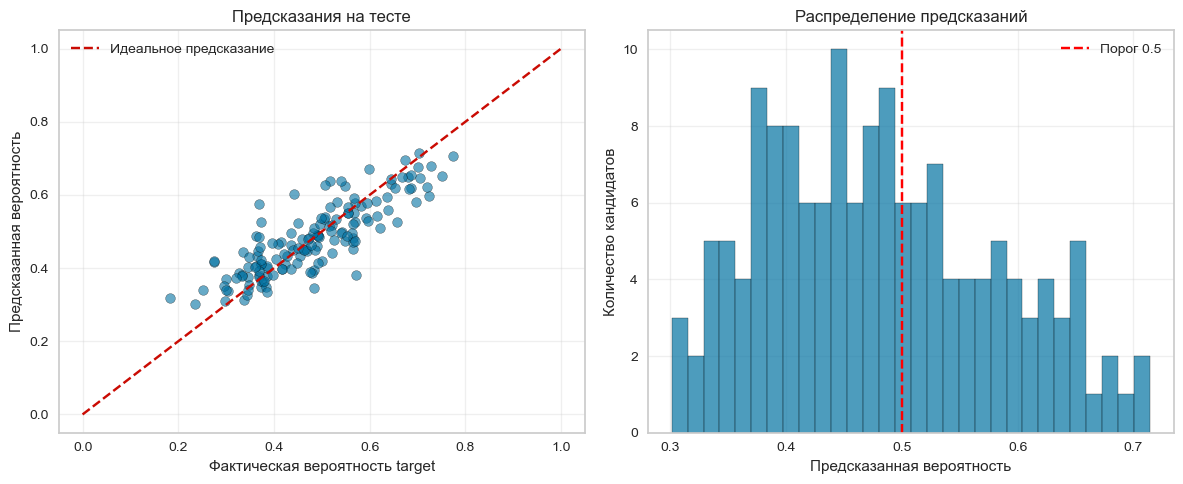

In [42]:
rf = RandomForestRegressor(random_state=42)

model_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", rf)
])

model_rf.fit(X_reg_train, y_proba_train)

y_pred_train_r = model_rf.predict(X_reg_train)
y_pred_test_r = model_rf.predict(X_reg_test)

res = calculate_metrics(model_rf, y_proba_test, y_pred_test_r, X_reg_test)

print(f'''Метрики Random Forest на тесте: \n
RMSE: {res['RMSE']:.4f} \n MAE: {res['MAE']:.4f} \n R2: {res['R2']:.4f}''')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_proba_test, y_pred_test_r, alpha=0.6, edgecolors='black')
plt.plot([0, 1], [0, 1], 'r--', label='Идеальное предсказание')
plt.xlabel('Фактическая вероятность target')
plt.ylabel('Предсказанная вероятность')
plt.title(f'Предсказания на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(y_pred_test_r, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0.5, color='red', linestyle='--', label='Порог 0.5')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Количество кандидатов')
plt.title('Распределение предсказаний')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* Модель объясняет 70.9% дисперсии целевой переменной, что чуть лучше случайных предсказаний
* В среднем модель ошибается на 0.05 пункта по шкале от 0 до 1. Средняя ошибка = 6.6%
* Многие предсказания расположены вдоль идеальной линии предсказания
* На распределении предсказаний видна ассиметрия с коротким хвостом справа 

Попробуем подобрать гиперпараметры для модели

In [43]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Сетка гиперпараметров
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"]
}

# GridSearch
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",  # RMSE
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_reg_train, y_proba_train)

print("Лучшие параметры:")
print(grid_search.best_params_)

print("\nЛучшее RMSE:")
print(grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Лучшие параметры:
{'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Лучшее RMSE:
-0.07782875168324252


Ошибка немного увеличилась. Обучим лес с этими гиперпараметрами

Метрики Random Forest на тесте: 

RMSE: 0.0719 
 MAE: 0.0582 
 R2: 0.6519


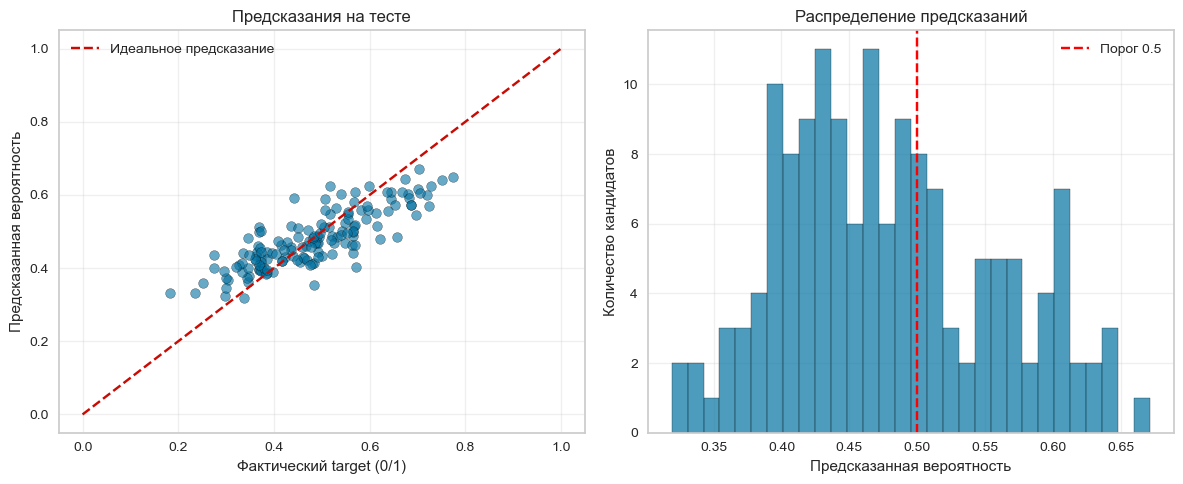

In [44]:
rf_tuned = RandomForestRegressor(
    max_depth=15, 
    max_features='sqrt', 
    min_samples_leaf=1, 
    min_samples_split=2, 
    n_estimators=200,
    random_state=42
)

model_rf_tuned = Pipeline([
    ("preprocess", preprocessor),
    ("model", rf_tuned)
])

model_rf_tuned.fit(X_reg_train, y_proba_train)

y_pred_train_r = model_rf_tuned.predict(X_reg_train)
y_pred_test_r = model_rf_tuned.predict(X_reg_test)

res_tuned = calculate_metrics(model_rf_tuned, y_proba_test, y_pred_test_r, X_reg_test)

print(f'''Метрики Random Forest на тесте: \n
RMSE: {res_tuned['RMSE']:.4f} \n MAE: {res_tuned['MAE']:.4f} \n R2: {res_tuned['R2']:.4f}''')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_proba_test, y_pred_test_r, alpha=0.6, edgecolors='black')
plt.plot([0, 1], [0, 1], 'r--', label='Идеальное предсказание')
plt.xlabel('Фактический target (0/1)')
plt.ylabel('Предсказанная вероятность')
plt.title(f'Предсказания на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(y_pred_test_r, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0.5, color='red', linestyle='--', label='Порог 0.5')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Количество кандидатов')
plt.title('Распределение предсказаний')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* Модель стала объяснять 65.2% дисперсии целевой переменной, стало хуже на 5%
* В среднем теперь модель ошибается на 0.06 пункта по шкале от 0 до 1. Средняя ошибка = 7.2%
* Многие предсказания также расположены вдоль идеальной линии предсказания
* На распределении предсказаний видна ещё большая ассиметрия с хвостом справа

Теперь сравним модели случайного леса. Перед этим создадим функцию для сравнения моделей

In [45]:
def table_metrics(model, x_train, x_test, y_train, y_test, model_name):

    '''Функция для таблицы сравнения моделей'''
    
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    return {
        "Модель": model_name,

        "Train MSE": mean_squared_error(y_train, y_pred_train),
        "Test MSE": mean_squared_error(y_test, y_pred_test),

        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),

        "Train MAE": mean_absolute_error(y_train, y_pred_train),
        "Test MAE": mean_absolute_error(y_test, y_pred_test),

        "Train R2": r2_score(y_train, y_pred_train),
        "Test R2": r2_score(y_test, y_pred_test)
    }

Сравним модели

In [49]:
result = []

model_rf.fit(X_reg_train, y_proba_train)

result.append(
    table_metrics(model_rf, X_reg_train, X_reg_test, y_proba_train, y_proba_test, "RF")
) 

model_rf_tuned.fit(X_reg_train, y_proba_train)

result.append(
    table_metrics(model_rf_tuned, X_reg_train, X_reg_test, y_proba_train, y_proba_test, "RF Tuned")
)

result_df = pd.DataFrame(result).round(4)
result_df

,Модель,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,RF,0.0008,0.0043,0.0281,0.0658,0.0226,0.0506,0.9502,0.7089
1,RF Tuned,0.0009,0.0052,0.0300,0.0719,0.0245,0.0582,0.9433,0.6519


Базовая модель лучше, чем с подобранными гиперпараметрами. Но есть переобучение моделей

Лучшая модель в случайном лесе - сбазовая

Попробуем увеличить min_samples_leaf с 1 до 10 и посмотрим, что выйдет у модели с подобранными гиперпараметрами

In [50]:
rf_tuned1 = RandomForestRegressor(
    max_depth=15, 
    max_features='sqrt', 
    min_samples_leaf=10, 
    min_samples_split=2, 
    n_estimators=200,
    random_state=42
)

model_rf_tuned1 = Pipeline([
    ("preprocess", preprocessor),
    ("model", rf_tuned1)
])

model_rf_tuned1.fit(X_reg_train, y_proba_train)

y_pred_train_r = model_rf_tuned1.predict(X_reg_train)
y_pred_test_r = model_rf_tuned1.predict(X_reg_test)

res_tuned1 = calculate_metrics(model_rf_tuned1, y_proba_test, y_pred_test_r, X_reg_test)

print(f'''Метрики Random Forest на тесте: \n
RMSE: {res_tuned1['RMSE']:.4f} \n MAE: {res_tuned1['MAE']:.4f} \n R2: {res_tuned1['R2']:.4f}''')

Метрики Random Forest на тесте: 

RMSE: 0.0812 
 MAE: 0.0670 
 R2: 0.5567


Показатели ухудшились. Возможно, мало наблюдений, поэтому модель переобучилась. Пока сохраним лучшую модель леса (базовую)

In [51]:
best_r = RandomForestRegressor(random_state=42)

best_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", best_r)
])

best_rf.fit(X_reg_train, y_proba_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['consulting_keywords_count',
                                                   'market_research_count',
                                                   'valuation_count',
                                                   'client_facing_count',
                                                   'leadership_count',
                                                   'project_management_count',
                                                   'presentation_count',
                                                   'communication_count',
                                                   'problem_solving_count',
                                                   'excel_count', 'sql_count',
                                                   'python_count',
                                                   'statistics_count',
                                                   'data_analysis_count',
                                                   'research_count',
                                                   'case_competitions_count']),
                                                 ('bin', 'passthrough',
                                                  ['top_university',
                                                   'internship', 'tech_major',
                                                   'econ_major',
                                                   'consulting_experience',
                                                   'big_brands', 'olympiads',
                                                   'scholarships', 'cfa',
                                                   'english_advanced',
                                                   'second_language'])])),
                ('model', RandomForestRegressor(random_state=42))])

Проведем кросс-валидацию модели леса

In [52]:
cv_rf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = cross_val_score(
    best_rf, X_reg_train, y_proba_train,
    cv=cv_rf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

mae_scores = -cross_val_score(
    best_rf, X_reg_train, y_proba_train,
    cv=cv_rf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

r2_scores = cross_val_score(
    best_rf, X_reg_train, y_proba_train,
    cv=cv_rf,
    scoring='r2',
    n_jobs=-1
)

print(f"RMSE \n{[f'{s:.4f}' for s in rmse_scores]} \nСреднее RMSE = {rmse_scores.mean():.4f} \nStd = {rmse_scores.std():.4f}\n")
print(f"MAE \n{[f'{s:.4f}' for s in mae_scores]} \nСреднее MAE = {mae_scores.mean():.4f} \nStd = {mae_scores.std():.4f}\n")
print(f"R2 \n{[f'{s:.4f}' for s in r2_scores]} \nСреднее R2 = {r2_scores.mean():.4f} \nStd = {r2_scores.std():.4f}\n")

RMSE 
['-0.0832', '-0.0753', '-0.0774', '-0.0722', '-0.0735'] 
Среднее RMSE = -0.0763 
Std = 0.0039

MAE 
['0.0651', '0.0582', '0.0641', '0.0606', '0.0606'] 
Среднее MAE = 0.0617 
Std = 0.0025

R2 
['0.5891', '0.6017', '0.6210', '0.6991', '0.6289'] 
Среднее R2 = 0.6279 
Std = 0.0383



Результаты на тесте лучше по $R^2$. По ошибкам на тесте немного лучше, чем на валидации

Теперь выберем подходящую модель бустинга

In [53]:
models = {
    "GradientBoosting": Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
    "AdaBoost": Pipeline([
        ("prep", preprocessor),
        ("model", AdaBoostRegressor(random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("model", xgb.XGBRegressor(
            eval_metric='rmse', 
            random_state=42
        ))
    ]),
    "LightGBM": Pipeline([
        ("prep", preprocessor),
        ("model", lgb.LGBMRegressor(  
            random_state=42,
            verbosity=-1
        ))
    ]),
    "CatBoost": Pipeline([
        ("prep", preprocessor),
        ("model", CatBoostRegressor(
            random_state=42,
            verbose=0
        ))
    ]),
}

results = []

for name, model in models.items():
    model.fit(X_reg_train, y_proba_train)
    y_pred_test = model.predict(X_reg_test)  

    results.append({
        "Model": name,  
        "MSE": mean_squared_error(y_test, y_pred_test),   
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "R2": r2_score(y_test, y_pred_test)
    })

df_results = pd.DataFrame(results)
df_results = df_results.set_index("Model").round(3)

df_results

,MSE,RMSE,MAE,R2
Model,,,,
GradientBoosting,0.253,0.503,0.493,-0.017
AdaBoost,0.250,0.500,0.494,-0.006
XGBoost,0.252,0.502,0.489,-0.012
LightGBM,0.256,0.506,0.495,-0.029
CatBoost,0.255,0.505,0.494,-0.023


Базовые модели бустинга без настройки все плохого качества и предсказывают вероятность принятия кандидата на работу хуже предсказания среднего значения. Среди них лучший результат показала модель AdaBoost. Её возьмём в проработку дальше 

In [54]:
ada = Pipeline([
    ("prep", preprocessor),
    ("model", AdaBoostRegressor(
        estimator=DecisionTreeRegressor(), 
        random_state=42                          
    ))
])

# Сетка параметров
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.05, 0.1, 0.2],          
    "model__estimator__max_depth": [3, 5, 7, None],     
    "model__estimator__min_samples_leaf": [1, 2, 5],    
    "model__estimator__max_features": ["sqrt", "log2", None]
}

# GridSearch
grid_search = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",  
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_reg_train, y_proba_train)

print("Лучшие параметры:")
print(grid_search.best_params_)

print("\nЛучшее RMSE:")
print(grid_search.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Лучшие параметры:
{'model__estimator__max_depth': 7, 'model__estimator__max_features': None, 'model__estimator__min_samples_leaf': 5, 'model__learning_rate': 0.2, 'model__n_estimators': 200}

Лучшее RMSE:
-0.07262995862253448


С подобранными гиперпараметрами обучим модель

Метрики AdaBoost на тесте: 

RMSE: 0.0657 
 MAE: 0.0517 
 R2: 0.7096


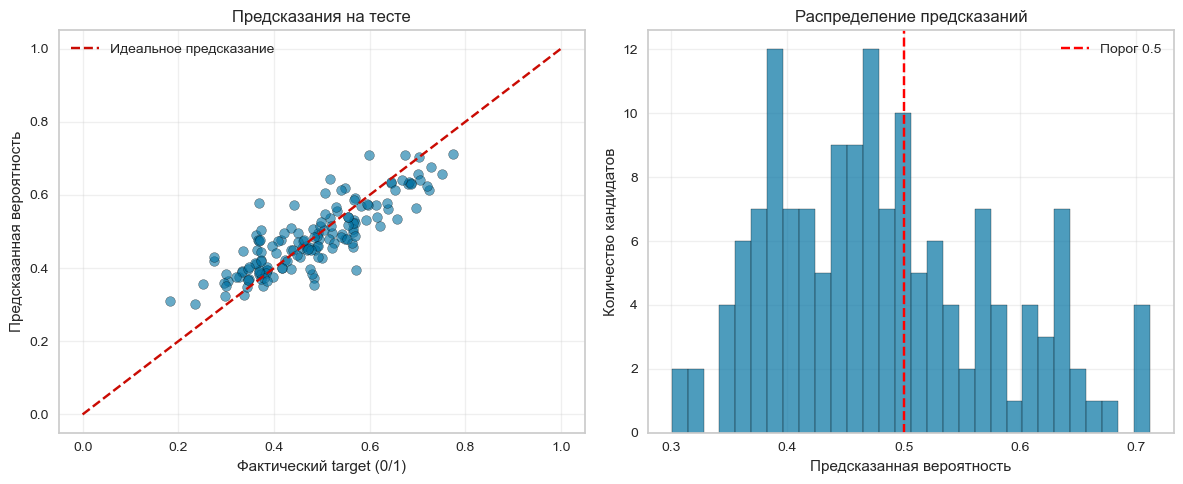

In [55]:
tree = DecisionTreeRegressor(
    max_depth=7,
    max_features=None,
    min_samples_leaf=5
)

best_a = AdaBoostRegressor(
    estimator=tree, 
    random_state=42, 
    learning_rate=0.2, 
    n_estimators=200
)

best_ada = Pipeline([
    ("preprocess", preprocessor),
    ("model", best_a)
])

best_ada.fit(X_reg_train, y_proba_train)

y_pred_train_r = best_ada.predict(X_reg_train)
y_pred_test_r = best_ada.predict(X_reg_test)

result = calculate_metrics(best_ada, y_proba_test, y_pred_test_r, X_reg_test)

print(f'''Метрики AdaBoost на тесте: \n
RMSE: {result['RMSE']:.4f} \n MAE: {result['MAE']:.4f} \n R2: {result['R2']:.4f}''')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_proba_test, y_pred_test_r, alpha=0.6, edgecolors='black')
plt.plot([0, 1], [0, 1], 'r--', label='Идеальное предсказание')
plt.xlabel('Фактический target (0/1)')
plt.ylabel('Предсказанная вероятность')
plt.title(f'Предсказания на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(y_pred_test_r, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0.5, color='red', linestyle='--', label='Порог 0.5')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Количество кандидатов')
plt.title('Распределение предсказаний')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Модель AdaBoost показала результаты лучше, чем случайный лес. Модель объясняет 70.96% дисперсии целевой переменной, это лучший результат 

Проведем кросс-валидацию

In [56]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = cross_val_score(
    best_ada, X_reg_train, y_proba_train, 
    cv=cv, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

mae_scores = cross_val_score(
    best_ada, X_reg_train, y_proba_train, 
    cv=cv, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

r2_scores = cross_val_score(
    best_ada, X_reg_train, y_proba_train, 
    cv=cv, 
    scoring='r2',
    n_jobs=-1
)

print(f"RMSE \n{[f'{s:.4f}' for s in rmse_scores]} \nСреднее RMSE = {rmse_scores.mean():.4f} \nStd = {rmse_scores.std():.4f}\n")
print(f"MAE \n{[f'{s:.4f}' for s in mae_scores]} \nСреднее MAE = {mae_scores.mean():.4f} \nStd = {mae_scores.std():.4f}\n")
print(f"R2 \n{[f'{s:.4f}' for s in r2_scores]} \nСреднее R2 = {r2_scores.mean():.4f} \nStd = {r2_scores.std():.4f}\n")

RMSE 
['-0.0816', '-0.0730', '-0.0747', '-0.0745', '-0.0720'] 
Среднее RMSE = -0.0751 
Std = 0.0034

MAE 
['-0.0647', '-0.0574', '-0.0607', '-0.0622', '-0.0599'] 
Среднее MAE = -0.0610 
Std = 0.0024

R2 
['0.6052', '0.6255', '0.6470', '0.6793', '0.6441'] 
Среднее R2 = 0.6402 
Std = 0.0246



Модель бустинга стабильна и не переобучена. Результаты на тесте лучше, чем на валидации

Теперь рассмотрим 3 модель регрессии

Оптимизация RandomForest...
  Лучшие параметры: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
  Лучший RMSE: 0.0739
Оптимизация XGBoost...
  Лучшие параметры: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
  Лучший RMSE: 0.0660
Оптимизация LightGBM...
  Лучшие параметры: {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 0.1, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  Лучший RMSE: 0.0654
Оптимизация CatBoost...
  Лучшие параметры: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 4}
  Лучший RMSE: 0.0661

Пробуем мета-модель: Ridge
  Средний RMSE (CV): 0.0669 (+/- 0.0041)

Пробуем мета-модель: LinearRegression
  Средний RMSE (CV): 0.0652 (+/- 0.0057)

Пробуем мета-модель: KNN
  Средний RMSE (CV): 0.0950 (+/- 0.0041)

Лучшая мета-модель: LinearRegression со средним RMSE = 0.0652

=== Результаты на тестовой в

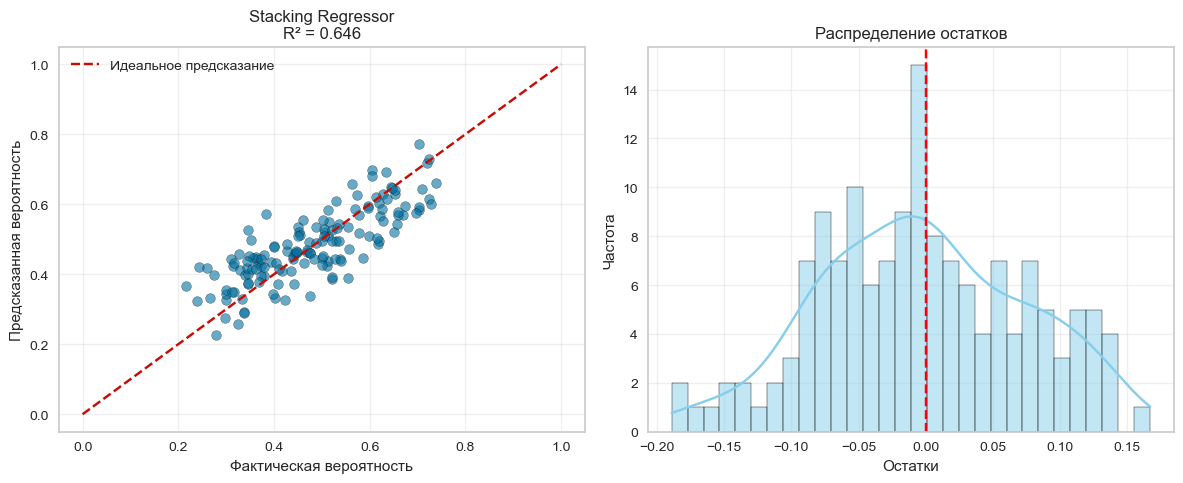

In [61]:
best_clf = LGBMClassifier(
    n_estimators=200, 
    max_depth=9, 
    learning_rate=0.01,
    subsample=1.0, 
    colsample_bytree=0.6, 
    reg_alpha=0.5, 
    reg_lambda=0.1,
    random_state=42, 
    n_jobs=-1, 
    verbose=-1 
)
y_proba_cv = cross_val_predict(best_clf, X, y, cv=5, method='predict_proba', n_jobs=-1)[:, 1]

# Разделение на train/test для регрессии 
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_proba_cv, test_size=0.25, random_state=42, stratify=y
)

# Применяем предобработку к X_train и X_test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

def optimize_model(model, param_dist, X_train, y_train, name, n_iter=20):
    print(f"Оптимизация {name}...")
    random_search = RandomizedSearchCV(
        model, param_dist, n_iter=n_iter, cv=5,
        scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42, verbose=0
    )
    random_search.fit(X_train, y_train)
    print(f"  Лучшие параметры: {random_search.best_params_}")
    print(f"  Лучший RMSE: {-random_search.best_score_:.4f}")
    return random_search.best_estimator_

# Базовые модели 
# Random Forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}
best_rff = optimize_model(RandomForestRegressor(random_state=42), rf_params, X_train_prep, y_train_reg, "RandomForest", n_iter=15)

# XGBoost
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
best_xgb = optimize_model(XGBRegressor(random_state=42, eval_metric='rmse'), xgb_params, X_train_prep, y_train_reg, "XGBoost", n_iter=15)

# LightGBM
lgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 9, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5]
}
best_lgb = optimize_model(lgb.LGBMRegressor(random_state=42, verbosity=-1), lgb_params, X_train_prep, y_train_reg, "LightGBM", n_iter=15)

# CatBoost
cat_params = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7]
}
best_cat = optimize_model(CatBoostRegressor(random_state=42, verbose=0), cat_params, X_train_prep, y_train_reg, "CatBoost", n_iter=15)

# Stacking Regressor с подбором гиперпараметров

# Список базовых моделей 
base_estimators = [
    ('rf', best_rff),
    ('xgb', best_xgb),
    ('lgb', best_lgb),
    ('cat', best_cat)
]

# Мета-модели для тестирования
meta_models = {
    'Ridge': Ridge(),
    'LinearRegression': LinearRegression(),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

best_stacking = None
best_score = -np.inf
best_meta_name = None

for meta_name, meta_model in meta_models.items():
    print(f"\nПробуем мета-модель: {meta_name}")
    stacking = StackingRegressor(
        estimators=base_estimators,
        final_estimator=meta_model,
        cv=5,
        passthrough=True  # передаём исходные признаки в мета-модель
    )
    # Кросс-валидация для оценки
    scores = cross_val_score(stacking, X_train_prep, y_train_reg, cv=5,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    mean_rmse = -scores.mean()
    print(f"  Средний RMSE (CV): {mean_rmse:.4f} (+/- {scores.std():.4f})")
    
    if mean_rmse < best_score or best_score == -np.inf:
        best_score = mean_rmse
        best_stacking = stacking
        best_meta_name = meta_name

print(f"\nЛучшая мета-модель: {best_meta_name} со средним RMSE = {best_score:.4f}")

# Обучаем лучший стекинг на всех обучающих данных
best_stacking.fit(X_train_prep, y_train_reg)

# Оценка на тестовой выборке

y_pred_stack = best_stacking.predict(X_test_prep)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_stack))
mae = mean_absolute_error(y_test_reg, y_pred_stack)
r2 = r2_score(y_test_reg, y_pred_stack)

print("\n=== Результаты на тестовой выборке (Stacking Regressor) ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

# Анализ важности признаков через мета-модель (если мета-модель линейная)

if best_meta_name in ['Ridge', 'LinearRegression']:
    # Получаем коэффициенты мета-модели
    coefs = best_stacking.final_estimator_.coef_
    # Важность соответствует весам базовых моделей и исходным признакам
    n_base = len(base_estimators)
    n_original = X_train_prep.shape[1]
    feature_names = [f'base_{name}' for name, _ in base_estimators] + [f'orig_{i}' for i in range(n_original)]
    importance_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    importance_df = importance_df.sort_values('coefficient', key=abs, ascending=False)
    print("\nТоп-10 коэффициентов мета-модели:")
    print(importance_df.head(10))
else:
    from sklearn.inspection import permutation_importance
    perm_importance = permutation_importance(best_stacking, X_test_prep, y_test_reg, n_repeats=10, random_state=42, n_jobs=-1)
    sorted_idx = perm_importance.importances_mean.argsort()[::-1]
    print("\nВажность признаков (permutation importance) для стекинга:")
    for i in sorted_idx[:10]:
        print(f"Признак {i}: {perm_importance.importances_mean[i]:.4f} (+/- {perm_importance.importances_std[i]:.4f})")


# Визуализация результатов
plt.figure(figsize=(12, 5))

# График предсказаний vs реальных значений
plt.subplot(1, 2, 1)
plt.scatter(y_test_reg, y_pred_stack, alpha=0.6, edgecolors='black')
plt.plot([0, 1], [0, 1], 'r--', label='Идеальное предсказание')
plt.xlabel('Фактическая вероятность')
plt.ylabel('Предсказанная вероятность')
plt.title(f'Stacking Regressor\nR² = {r2:.3f}')
plt.legend()
plt.grid(alpha=0.3)

# Гистограмма остатков
plt.subplot(1, 2, 2)
residuals = y_test_reg - y_pred_stack
sns.histplot(residuals, bins=30, kde=True, color='skyblue')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Качество модели

**Stacking Regressor** (мета-модель — LinearRegression) был обучен на предсказаниях четырёх базовых моделей: Random Forest, XGBoost, LightGBM и CatBoost.

**Метрики на тестовой выборке**

| Метрика | Значение |
|---------|----------|
| **RMSE** | 0.0761 |
| **MAE**  | 0.0613 |
| **R²**   | **0.6459** |

Модель объясняет **64.6%** дисперсии целевой переменной (вероятности получения оффера). Это приемлемый результат для задачи прогнозирования на основе текстов резюме.  
Средняя ошибка предсказания составляет около **0.0613** по шкале вероятностей (т.е. ~6.13 процентных пункта).

### Анализ коэффициентов мета-модели

Мета-модель (LinearRegression) обучалась на предсказаниях базовых моделей и исходных признаках. Наибольшее влияние на итоговый прогноз оказывают `base_cat` и `base_lgb`. Это ключевые модели для итогового прогноза. Причем исходные признаки имеют почти нулевые коэффициенты, подтверждает, что базовые модели эффективно извлекли информацию из данных.

На тестовой выборке стекинг показал **$R^2$ = 0.646**, что ниже, чем у модели бустинга 

Теперь сравним модели

In [62]:
results = []

best_rf.fit(X_reg_train, y_proba_train)

results.append(
    table_metrics(best_rf, X_reg_train, X_reg_test, y_proba_train, y_proba_test, "RF")
)

best_ada.fit(X_reg_train, y_proba_train)

results.append(
    table_metrics(best_ada, X_reg_train, X_reg_test, y_proba_train, y_proba_test, "AdaBoost")
)

best_stacking.fit(X_reg_train, y_proba_train)
results.append(
    table_metrics(best_stacking, X_reg_train, X_reg_test, y_proba_train, y_proba_test, "Stacking Regressor")
)

results_df = pd.DataFrame(results).round(4)
results_df

,Модель,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,RF,0.0008,0.0043,0.0281,0.0658,0.0226,0.0506,0.9502,0.7089
1,AdaBoost,0.0018,0.0043,0.0426,0.0657,0.0371,0.0517,0.8852,0.7096
2,Stacking Regressor,0.0017,0.0040,0.0407,0.0630,0.0330,0.0501,0.8956,0.7327


Модель стекинга показывает лучший результат, при этом она не так сильно переобучена как случайный лес и AdaBoost. По всем результатам она превосходит другие модели регрессии, на 2 месте AdaBoost, далее случайный лес

Однако у всех моделей наблюдается переобучение, что может быть связано с количеством наблюдений

**Ключевые выводы**

1. **Финансовая аналитика и оценка бизнеса** - самый сильный предиктор успешного найма (`valuation_count`, `cfa`). Это подтверждает специфику консалтинговых позиций, где требуются навыки финансового моделирования.

2. **Soft skills без подтверждения проектами не работают** - кандидаты, перечисляющие общие коммуникативные и презентационные навыки без конкретных достижений, реже получают оффер.

3. **Практический опыт важнее формального образования** - кейс-чемпионаты, стажировки, опыт в известных компаниях (big brands) и знание английского языка дают большее преимущество, чем просто диплом топ-вуза.

4. **Технические навыки (Python, SQL) имеют среднюю значимость** - они важны, но в контексте консалтинга уступают бизнес-компетенциям.

5. **Кластеризация выделила 4 устойчивых профиля кандидатов**:
   - **«Звёзды» (12%)** - лучшие кандидаты, успех в 60% случаев.
   - **«Начинающие универсалы» (58%)** - хорошие soft skills, средний успех (49%).
   - **«Амбициозные консалтеры-самоучки» (13%)** - высокая ориентация на консалтинг, но слабый английский (успех 39.2%).
   - **«Экономисты в консалтинге» (17%)** - сильные экономические навыки, но низкие академические показатели (успех 33.7%).

6. **Лучшая модель классификации** - KNN лучшая модель по Accuracy (0.57), Precision (0.55). Но LightGBM показал лучший Recall (0,48), что важнее для HR-скрининга.

7. Для регрессионного прогнозирования вероятности успеха наилучшей моделью оказался Stacking Regressor ($R^2$ = 0.7327, RMSE = 0.0630), объединяющий CatBoost, LightGBM, XGBoost и Random Forest. 

8. **Качество прогнозирования остаётся умеренным** (ROC‑AUC ~0,58). Это объясняется сложностью задачи - успех найма зависит от многих ненаблюдаемых факторов (мотивация, soft skills в интервью, cultural fit).

### Ограничения исследования

1. **Небольшой объём выборки** - 597 резюме. Этого достаточно для базового анализа, но для более точных моделей желательно 2000+ наблюдений.

2. **Отсутствие временной валидации** - данные собраны за один период, нет проверки на разных временных срезах (могут быть сезонные колебания в найме).

3. **Только текстовые признаки** - не учитывались такие факторы, как возраст, пол, географическое положение, опыт работы (количество лет), которые также влияют на решение.

4. **Ручной подбор ключевых слов** - словари признаков составлялись на основе экспертных интервью, но могут быть неполными или содержать шум.

5. **Ограниченная обобщаемость** - данные получены из одной компании («Б1»). Результаты могут не переноситься на другие консалтинговые фирмы с иными требованиями.

6. **Дисбаланс классов отсутствует** (53% / 47%), но модели всё равно показывают невысокую полноту по классу «принят».

7. **Отсутствие сравнения с глубокими методами** - не применялись эмбеддинги (BERT, Sentence‑BERT) и нейросетевые подходы, которые могли бы улучшить качество.